**HÜCRE 1: ORTAM KURULUMU, VERİ YÜKLEME VE KEŞİFSEL VERİ ANALİZİ (EDA)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kütüphaneler yüklendi.
Veri yüklendi: 4424 satır × 35 sütun

VERİ SETİ TEMEL BİLGİLERİ
Satır (öğrenci): 4424
Sütun (öznitelik): 35
Bellek: 1420.1 KB

Eksik değer: 0
Tekrar eden satır: 0

Hedef değişken: 'Target'
Sınıflar: ['Dropout' 'Graduate' 'Enrolled']

Sınıf Dağılımı:
  Graduate    :  2209 (%49.9)
  Dropout     :  1421 (%32.1)
  Enrolled    :   794 (%17.9)


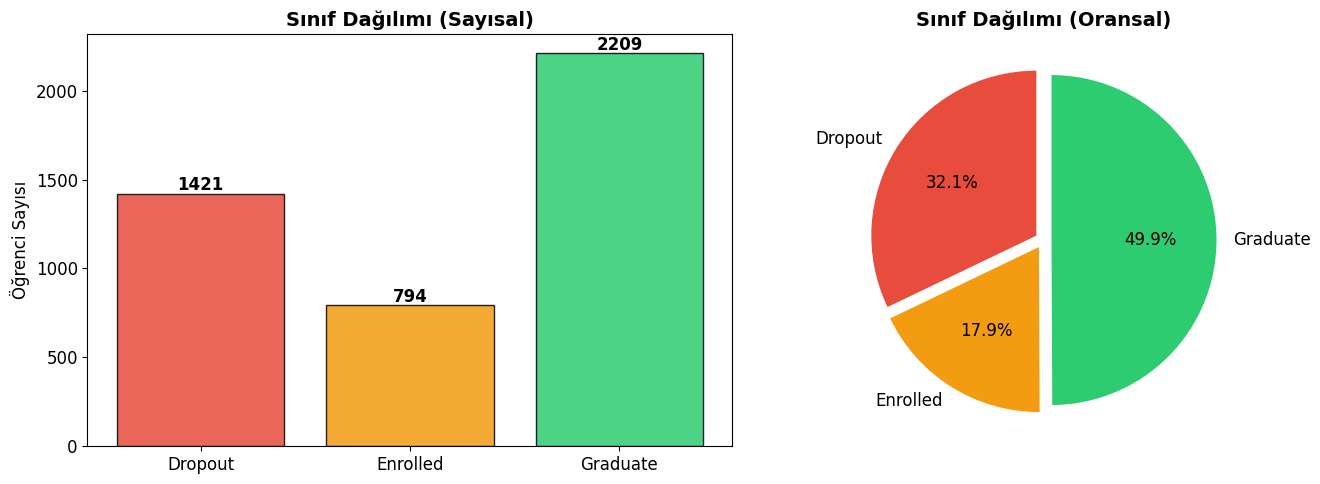


DEĞİŞKEN GRUPLANDIRMASI

Demografik (4 değişken):
  - Marital status
  - Gender
  - Age at enrollment
  - International

Sosyoekonomik (9 değişken):
  - Mother's qualification
  - Father's qualification
  - Mother's occupation
  - Father's occupation
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Scholarship holder

Akademik (17 değişken):
  - Application mode
  - Application order
  - Course
  - Daytime/evening attendance
  - Previous qualification
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)

Ma

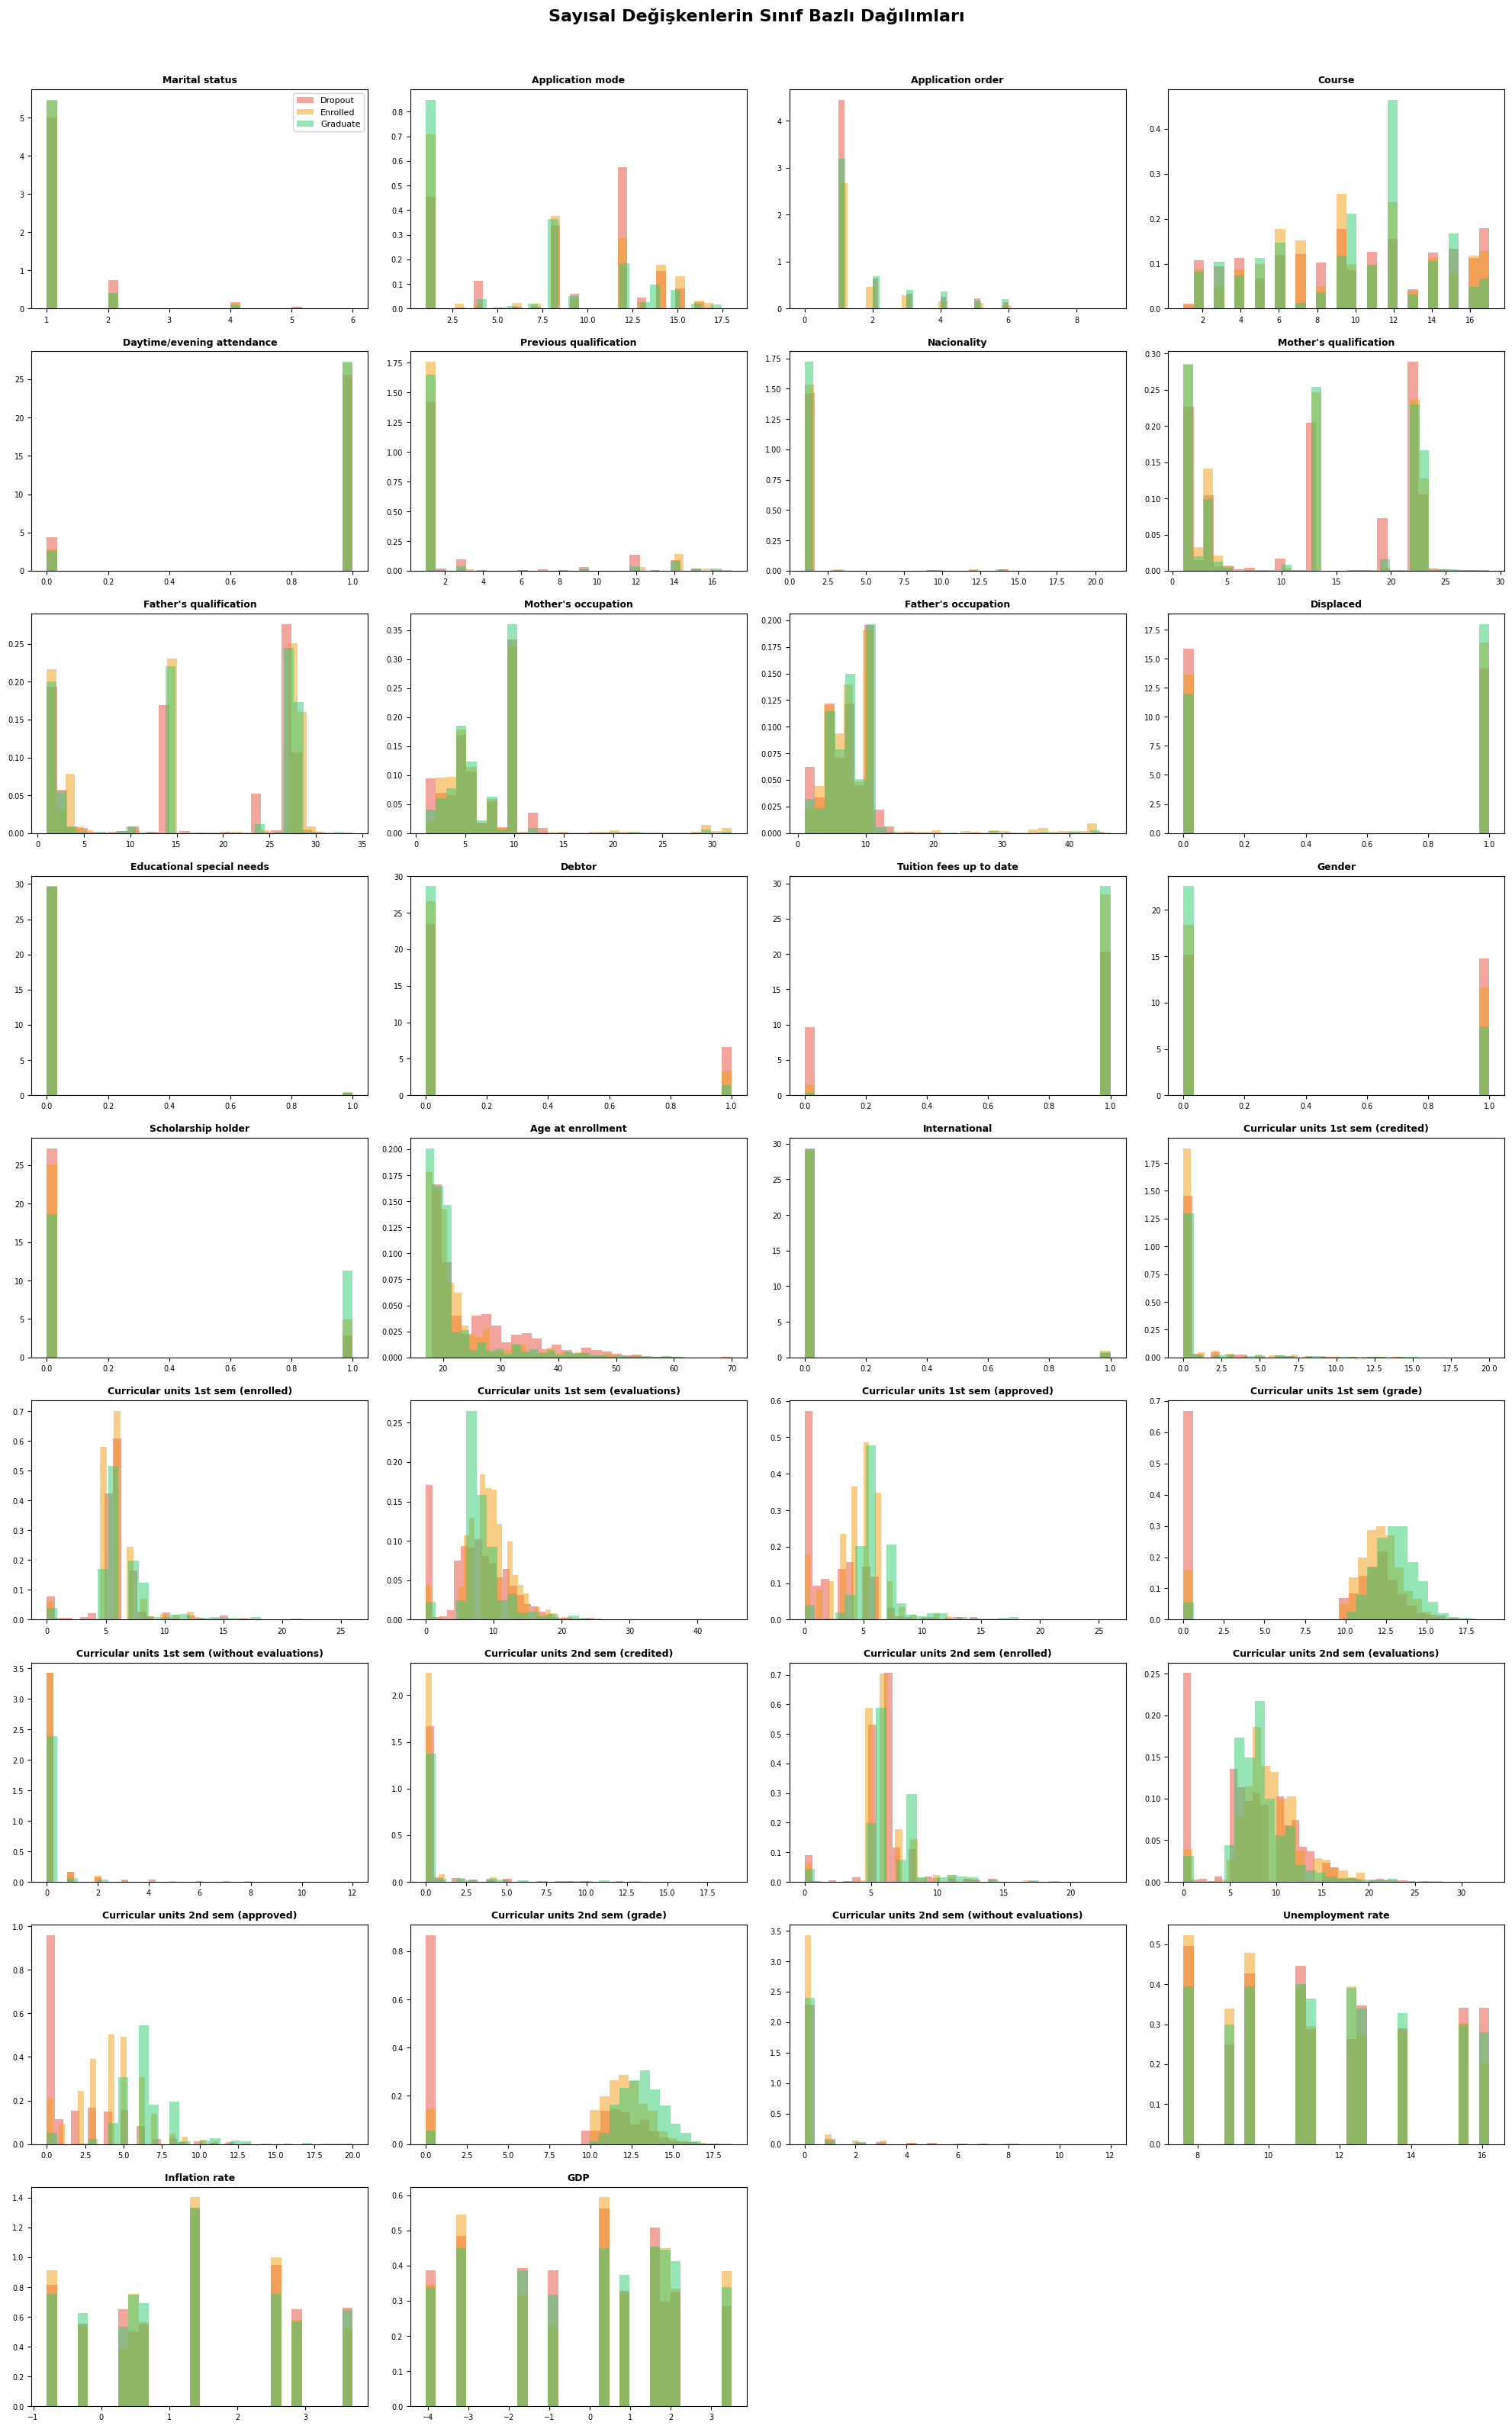

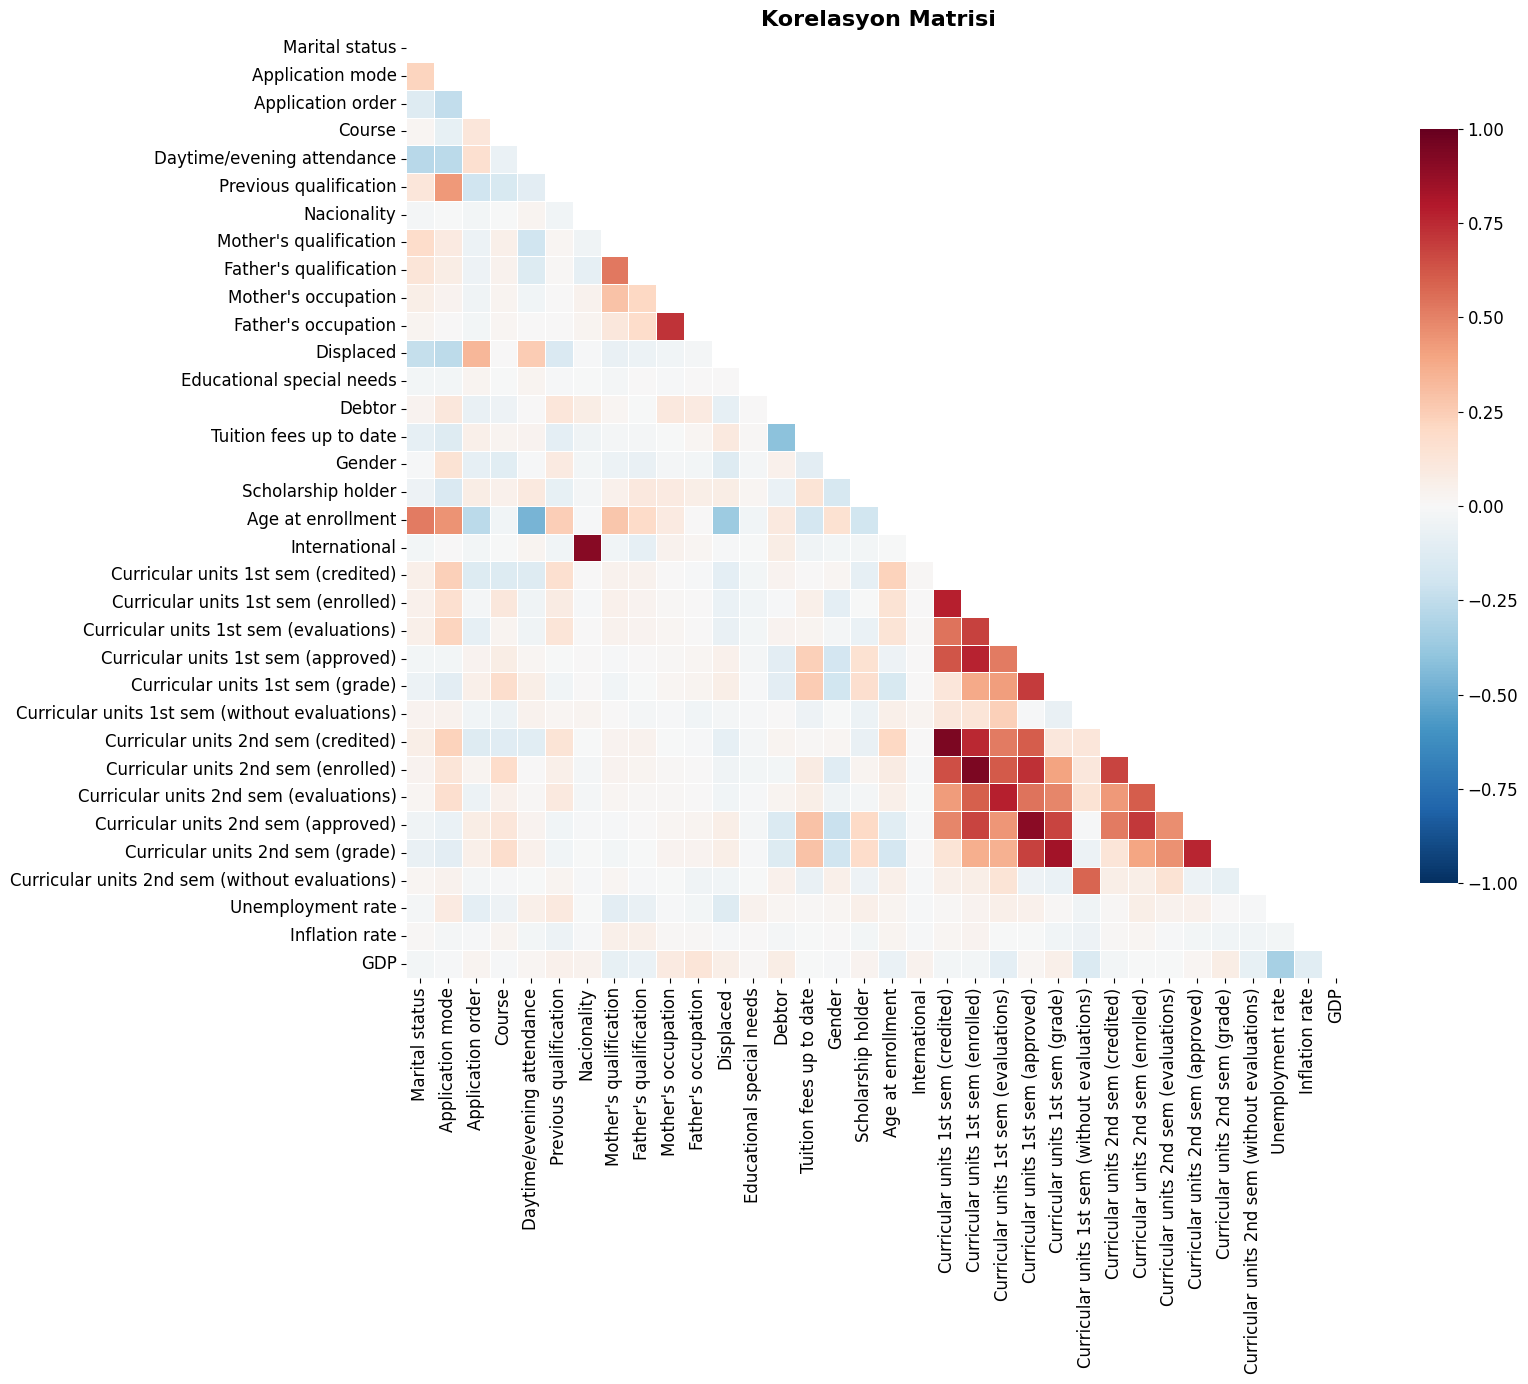


ÇARPIKLIK VE AYKIRI DEĞER ÖZETİ
Yüksek çarpıklığa sahip (|skew|>2): 15 değişken
Aykırı değer içeren: 25 değişken

✅ HÜCRE 1 TAMAMLANDI


In [ ]:
# =============================================================================
# HÜCRE 1: ORTAM KURULUMU, VERİ YÜKLEME VE KEŞİFSEL VERİ ANALİZİ (EDA)
# =============================================================================

# --- 1.0 Google Drive Bağlantısı ve Dizin Yapısı ---
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_Student_Dropout_v2'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'models')
for d in [PROJECT_DIR, DATA_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42

# --- 1.1 Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 100, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12
})

print("Kütüphaneler yüklendi.")

# --- 1.2 Veri Yükleme ---
csv_path = os.path.join(DATA_DIR, 'dataset.csv')
if not os.path.exists(csv_path):
    alternatives = ['data.csv', 'dataset.csv',
                    'predict students dropout and academic success.csv']
    found = False
    for alt in alternatives:
        alt_path = os.path.join(DATA_DIR, alt)
        if os.path.exists(alt_path):
            csv_path = alt_path
            found = True
            break
    if not found:
        raise FileNotFoundError(
            f"CSV dosyası bulunamadı. Lütfen veri dosyasını {DATA_DIR} dizinine yükleyin."
        )

# Delimiter otomatik algılama
df = pd.read_csv(csv_path, sep=';')
if df.shape[1] < 5:
    df = pd.read_csv(csv_path, sep=',')
print(f"Veri yüklendi: {df.shape[0]} satır × {df.shape[1]} sütun")

# --- 1.3 Temel Bilgiler ---
print("\n" + "=" * 70)
print("VERİ SETİ TEMEL BİLGİLERİ")
print("=" * 70)
print(f"Satır (öğrenci): {df.shape[0]}")
print(f"Sütun (öznitelik): {df.shape[1]}")
print(f"Bellek: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\nEksik değer: {df.isnull().sum().sum()}")
print(f"Tekrar eden satır: {df.duplicated().sum()}")

# Tekrar edenleri sil
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Tekrar edenler silindi → Yeni boyut: {df.shape}")

# --- 1.4 Hedef Değişken Analizi ---
target_col = 'Target'
print(f"\nHedef değişken: '{target_col}'")
print(f"Sınıflar: {df[target_col].unique()}")
print(f"\nSınıf Dağılımı:")
for cls, cnt in df[target_col].value_counts().items():
    print(f"  {cls:12s}: {cnt:5d} (%{cnt/len(df)*100:.1f})")

# --- 1.5 Hedef Değişken Görselleştirmesi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_target = {'Dropout': '#e74c3c', 'Enrolled': '#f39c12', 'Graduate': '#2ecc71'}
order = ['Dropout', 'Enrolled', 'Graduate']
counts = df[target_col].value_counts()

ax = axes[0]
bars = ax.bar(order, [counts[c] for c in order],
              color=[colors_target[c] for c in order], edgecolor='black', alpha=0.85)
ax.set_title('Sınıf Dağılımı (Sayısal)', fontweight='bold')
ax.set_ylabel('Öğrenci Sayısı')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height())}', ha='center', fontweight='bold')

axes[1].pie([counts[c] for c in order], labels=order,
            colors=[colors_target[c] for c in order],
            autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Sınıf Dağılımı (Oransal)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 1.6 Değişken Gruplandırması ---
print("\n" + "=" * 70)
print("DEĞİŞKEN GRUPLANDIRMASI")
print("=" * 70)

demographic = [c for c in df.columns if any(k in c.lower() for k in
    ['marital', 'gender', 'age', 'nationality', 'internacional', 'international'])]
socioeconomic = [c for c in df.columns if any(k in c.lower() for k in
    ['mother', 'father', 'scholarship', 'debtor', 'tuition', 'displaced',
     'educational special'])]
academic = [c for c in df.columns if any(k in c.lower() for k in
    ['curricular', 'admission', 'previous qualification', 'application',
     'course', 'daytime'])]
macro = [c for c in df.columns if any(k in c.lower() for k in
    ['unemployment', 'inflation', 'gdp'])]

groups = {'Demografik': demographic, 'Sosyoekonomik': socioeconomic,
          'Akademik': academic, 'Makroekonomik': macro}
for name, cols in groups.items():
    print(f"\n{name} ({len(cols)} değişken):")
    for c in cols:
        print(f"  - {c}")

# --- 1.7 Sayısal Değişkenlerin Dağılımı ---
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols_plot = 4
n_rows_plot = (len(numerical_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 3.5))
axes_flat = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes_flat[idx]
    for cls, color in colors_target.items():
        subset = df[df[target_col] == cls][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=cls, density=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)

for idx in range(len(numerical_cols), len(axes_flat)):
    axes_flat[idx].set_visible(False)

axes_flat[0].legend(fontsize=8)
plt.suptitle('Sayısal Değişkenlerin Sınıf Bazlı Dağılımları', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_numerical_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 1.8 Korelasyon Matrisi ---
fig, ax = plt.subplots(figsize=(18, 14))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            fmt='.1f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax.set_title('Korelasyon Matrisi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 1.9 Çarpıklık ve Aykırı Değer Özeti ---
print("\n" + "=" * 70)
print("ÇARPIKLIK VE AYKIRI DEĞER ÖZETİ")
print("=" * 70)

skew_info = []
for col in numerical_cols:
    skew_val = df[col].skew()
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    skew_info.append({'Değişken': col, 'Çarpıklık': skew_val,
                      'Aykırı Değer': n_outliers, '|Skew|>2': abs(skew_val) > 2})

skew_df = pd.DataFrame(skew_info)
high_skew = skew_df[skew_df['|Skew|>2']]
has_outlier = skew_df[skew_df['Aykırı Değer'] > 0]
print(f"Yüksek çarpıklığa sahip (|skew|>2): {len(high_skew)} değişken")
print(f"Aykırı değer içeren: {len(has_outlier)} değişken")

print("\n✅ HÜCRE 1 TAMAMLANDI")


**HÜCRE 2: VERİ ÖN İŞLEME VE ÖZELLİK MÜHENDİSLİĞİ**

AŞAMA 2: VERİ ÖN İŞLEME VE ÖZELLİK MÜHENDİSLİĞİ

Target Encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

--------------------------------------------------
2.2 AYKIRI DEĞER İŞLEME (IQR Capping)
--------------------------------------------------
Kırpma uygulanan değişken: 15
  Previous qualification: 707 aykırı değer kırpıldı
  Nacionality: 110 aykırı değer kırpıldı
  Mother's occupation: 84 aykırı değer kırpıldı
  Father's occupation: 84 aykırı değer kırpıldı
  Age at enrollment: 441 aykırı değer kırpıldı
  ... ve 10 değişken daha

--------------------------------------------------
2.3 ÖZELLİK MÜHENDİSLİĞİ (10 Yeni Öznitelik)
--------------------------------------------------

Türetilen 10 yeni öznitelik:
  F 1. Grade_Change              → 2.dönem notu - 1.dönem notu (akademik gelişim)
  F 2. Success_Rate_1st          → 1.dönem onaylanan / kayıtlı ders oranı
  F 3. Success_Rate_2nd          → 2.dönem onaylanan / kayıtlı ders oranı
  F 4. Total_Appro

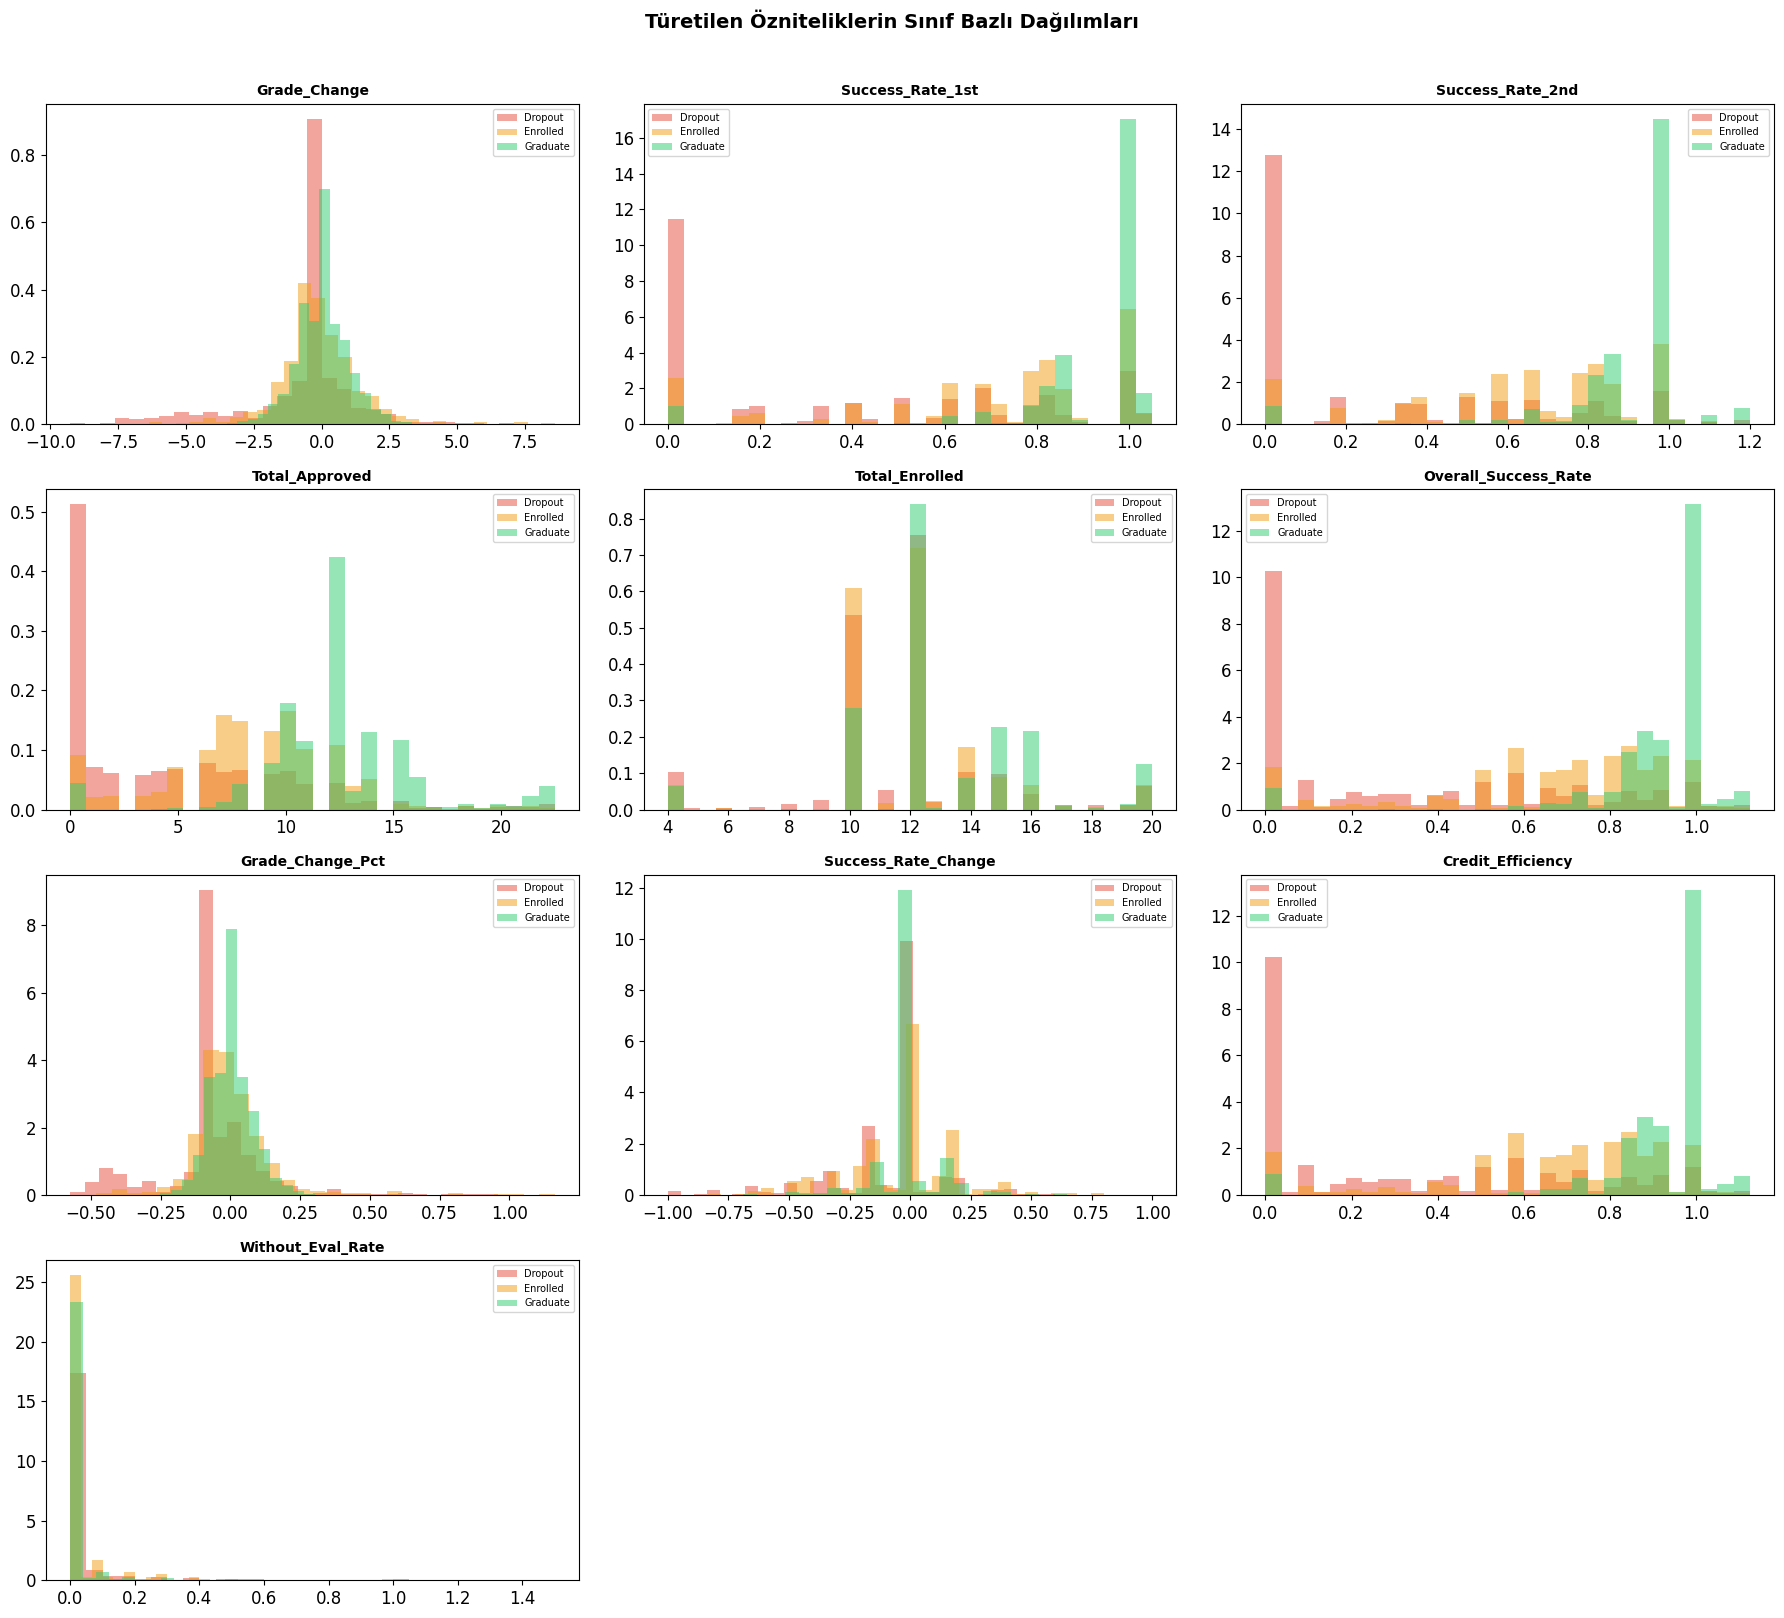


--------------------------------------------------
2.4 LOG DÖNÜŞÜMÜ
--------------------------------------------------
Log dönüşümü uygulanan: 6 değişken
  Marital status → log_Marital status (skew: 4.40 → 3.51)
  Educational special needs → log_Educational special needs (skew: 9.15 → 9.15)
  Tuition fees up to date → log_Tuition fees up to date (skew: -2.35 → -2.35)
  Curricular units 1st sem (without evaluations) → log_Curricular units 1st sem (without evaluations) (skew: 8.21 → 4.64)
  Curricular units 2nd sem (without evaluations) → log_Curricular units 2nd sem (without evaluations) (skew: 7.27 → 4.70)
  Without_Eval_Rate → log_Without_Eval_Rate (skew: 6.59 → 5.39)

--------------------------------------------------
2.5 ÖZELLİK SEÇİMİ (3 Aşamalı Filtre)
--------------------------------------------------

1) Yüksek korelasyon (>0.85): 11 değişken elenecek
2) Kruskal-Wallis (p≥0.05): 7 değişken anlamsız
     - Course
     - Father's qualification
     - Mother's occupation
     - Fa

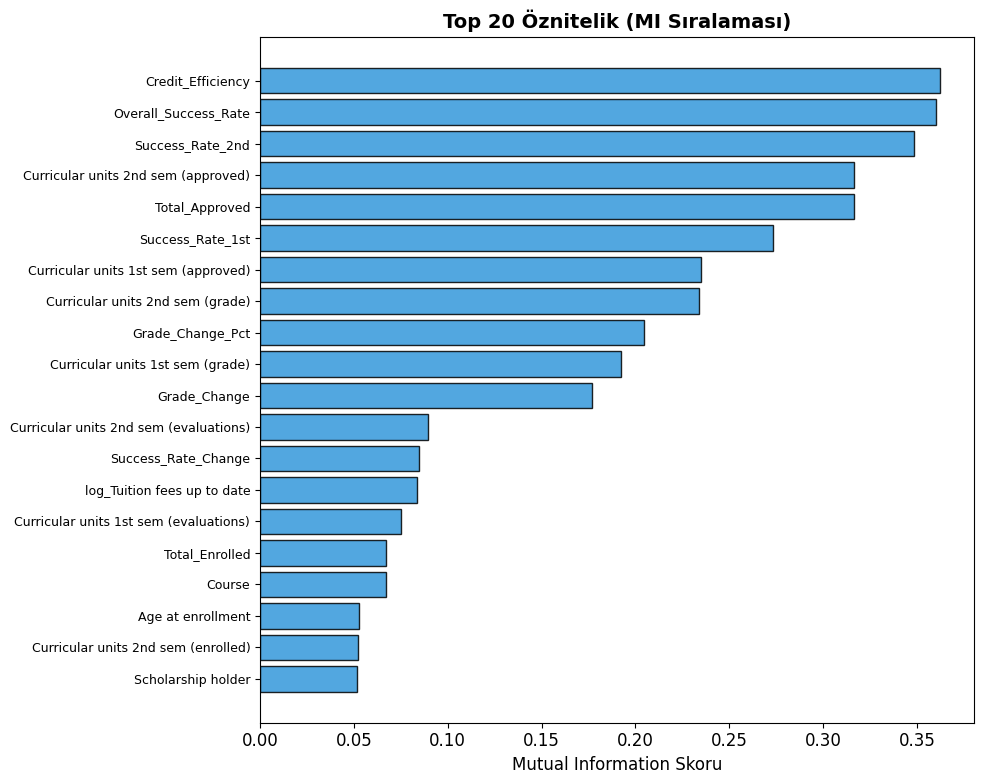


Güncel veri boyutu: (4424, 46)

✅ HÜCRE 2 TAMAMLANDI


In [ ]:
# =============================================================================
# HÜCRE 2: VERİ ÖN İŞLEME VE ÖZELLİK MÜHENDİSLİĞİ
# =============================================================================
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import kruskal

print("=" * 70)
print("AŞAMA 2: VERİ ÖN İŞLEME VE ÖZELLİK MÜHENDİSLİĞİ")
print("=" * 70)

df_processed = df.copy()

# --- 2.1 Hedef Değişken Encoding ---
le = LabelEncoder()
df_processed['Target_encoded'] = le.fit_transform(df_processed[target_col])
target_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\nTarget Encoding: {target_mapping}")

# --- 2.2 Aykırı Değer İşleme (IQR Capping) ---
print("\n" + "-" * 50)
print("2.2 AYKIRI DEĞER İŞLEME (IQR Capping)")
print("-" * 50)

continuous_cols = [c for c in numerical_cols if df_processed[c].nunique() >= 15]
capping_report = []

for col in continuous_cols:
    q1 = df_processed[col].quantile(0.25)
    q3 = df_processed[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_before = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    if n_before > 0:
        df_processed[col] = df_processed[col].clip(lower=lower, upper=upper)
        capping_report.append({'Değişken': col, 'Aykırı Değer': n_before,
                               'Alt Sınır': round(lower, 2), 'Üst Sınır': round(upper, 2)})

print(f"Kırpma uygulanan değişken: {len(capping_report)}")
for r in capping_report[:5]:
    print(f"  {r['Değişken']}: {r['Aykırı Değer']} aykırı değer kırpıldı")
if len(capping_report) > 5:
    print(f"  ... ve {len(capping_report)-5} değişken daha")

# --- 2.3 Özellik Mühendisliği (10 Yeni Öznitelik) ---
print("\n" + "-" * 50)
print("2.3 ÖZELLİK MÜHENDİSLİĞİ (10 Yeni Öznitelik)")
print("-" * 50)

epsilon = 1e-8
new_features = []

# Sütun isimlerini dinamik bul
sem1_approved = [c for c in df_processed.columns if 'approved' in c.lower() and '1st' in c]
sem2_approved = [c for c in df_processed.columns if 'approved' in c.lower() and '2nd' in c]
sem1_enrolled = [c for c in df_processed.columns if 'enrolled' in c.lower() and '1st' in c]
sem2_enrolled = [c for c in df_processed.columns if 'enrolled' in c.lower() and '2nd' in c]
sem1_grade    = [c for c in df_processed.columns if 'grade' in c.lower() and '1st' in c]
sem2_grade    = [c for c in df_processed.columns if 'grade' in c.lower() and '2nd' in c]
sem1_eval     = [c for c in df_processed.columns if 'evaluation' in c.lower() and '1st' in c]
sem2_eval     = [c for c in df_processed.columns if 'evaluation' in c.lower() and '2nd' in c]
sem1_without  = [c for c in df_processed.columns if 'without' in c.lower() and '1st' in c]
sem2_without  = [c for c in df_processed.columns if 'without' in c.lower() and '2nd' in c]
sem1_credited = [c for c in df_processed.columns if 'credited' in c.lower() and '1st' in c]
sem2_credited = [c for c in df_processed.columns if 'credited' in c.lower() and '2nd' in c]

# F1: Grade_Change = 2.dönem notu - 1.dönem notu
if sem1_grade and sem2_grade:
    df_processed['Grade_Change'] = df_processed[sem2_grade[0]] - df_processed[sem1_grade[0]]
    new_features.append('Grade_Change')

# F2: Success_Rate_1st = 1.dönem onaylanan/kayıtlı
if sem1_approved and sem1_enrolled:
    df_processed['Success_Rate_1st'] = (
        df_processed[sem1_approved[0]] / (df_processed[sem1_enrolled[0]] + epsilon)
    )
    new_features.append('Success_Rate_1st')

# F3: Success_Rate_2nd = 2.dönem onaylanan/kayıtlı
if sem2_approved and sem2_enrolled:
    df_processed['Success_Rate_2nd'] = (
        df_processed[sem2_approved[0]] / (df_processed[sem2_enrolled[0]] + epsilon)
    )
    new_features.append('Success_Rate_2nd')

# F4: Total_Approved = toplam onaylanan ders
if sem1_approved and sem2_approved:
    df_processed['Total_Approved'] = df_processed[sem1_approved[0]] + df_processed[sem2_approved[0]]
    new_features.append('Total_Approved')

# F5: Total_Enrolled = toplam kayıtlı ders
if sem1_enrolled and sem2_enrolled:
    df_processed['Total_Enrolled'] = df_processed[sem1_enrolled[0]] + df_processed[sem2_enrolled[0]]
    new_features.append('Total_Enrolled')

# F6: Overall_Success_Rate = genel başarı oranı
if 'Total_Approved' in df_processed.columns and 'Total_Enrolled' in df_processed.columns:
    df_processed['Overall_Success_Rate'] = (
        df_processed['Total_Approved'] / (df_processed['Total_Enrolled'] + epsilon)
    )
    new_features.append('Overall_Success_Rate')

# F7: Grade_Change_Pct = not değişim yüzdesi
if sem1_grade and sem2_grade:
    df_processed['Grade_Change_Pct'] = (
        (df_processed[sem2_grade[0]] - df_processed[sem1_grade[0]])
        / (df_processed[sem1_grade[0]] + epsilon)
    )
    new_features.append('Grade_Change_Pct')

# F8: Success_Rate_Change = başarı oranı değişimi
if 'Success_Rate_1st' in df_processed.columns and 'Success_Rate_2nd' in df_processed.columns:
    df_processed['Success_Rate_Change'] = (
        df_processed['Success_Rate_2nd'] - df_processed['Success_Rate_1st']
    )
    new_features.append('Success_Rate_Change')

# F9: Credit_Efficiency = (toplam onaylanan + toplam muaf) / (toplam kayıtlı)
if sem1_credited and sem2_credited and 'Total_Approved' in df_processed.columns and 'Total_Enrolled' in df_processed.columns:
    total_credited = df_processed[sem1_credited[0]] + df_processed[sem2_credited[0]]
    df_processed['Credit_Efficiency'] = (
        (df_processed['Total_Approved'] + total_credited) / (df_processed['Total_Enrolled'] + epsilon)
    )
    new_features.append('Credit_Efficiency')

# F10: Without_Eval_Rate = değerlendirmesiz ders oranı
if sem1_without and sem2_without and sem1_enrolled and sem2_enrolled:
    total_without = df_processed[sem1_without[0]] + df_processed[sem2_without[0]]
    total_enr = df_processed[sem1_enrolled[0]] + df_processed[sem2_enrolled[0]]
    df_processed['Without_Eval_Rate'] = total_without / (total_enr + epsilon)
    new_features.append('Without_Eval_Rate')

print(f"\nTüretilen {len(new_features)} yeni öznitelik:")
feature_descriptions = {
    'Grade_Change': '2.dönem notu - 1.dönem notu (akademik gelişim)',
    'Success_Rate_1st': '1.dönem onaylanan / kayıtlı ders oranı',
    'Success_Rate_2nd': '2.dönem onaylanan / kayıtlı ders oranı',
    'Total_Approved': 'Toplam onaylanan ders sayısı (1+2. dönem)',
    'Total_Enrolled': 'Toplam kayıtlı ders sayısı (1+2. dönem)',
    'Overall_Success_Rate': 'Genel başarı oranı (onaylanan/kayıtlı)',
    'Grade_Change_Pct': 'Not değişim yüzdesi',
    'Success_Rate_Change': 'Başarı oranındaki dönemler arası değişim',
    'Credit_Efficiency': 'Kredi verimliliği (onaylanan+muaf) / kayıtlı',
    'Without_Eval_Rate': 'Değerlendirmesiz ders oranı'
}
for i, f in enumerate(new_features, 1):
    print(f"  F{i:2d}. {f:25s} → {feature_descriptions.get(f, '')}")

# --- Yeni özniteliklerin görselleştirilmesi ---
n_new = len(new_features)
n_cols_nf = min(3, n_new)
n_rows_nf = (n_new + n_cols_nf - 1) // n_cols_nf

fig, axes = plt.subplots(n_rows_nf, n_cols_nf, figsize=(6*n_cols_nf, 4*n_rows_nf))
if n_new == 1: axes = [axes]
else: axes = axes.flatten()

for idx, feat in enumerate(new_features):
    ax = axes[idx]
    for cls, color in colors_target.items():
        subset = df_processed[df_processed[target_col] == cls][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=cls, density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

for idx in range(n_new, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Türetilen Özniteliklerin Sınıf Bazlı Dağılımları', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_new_features.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 2.4 Log Dönüşümü (Yüksek Çarpıklık) ---
print("\n" + "-" * 50)
print("2.4 LOG DÖNÜŞÜMÜ")
print("-" * 50)

all_num = [c for c in df_processed.select_dtypes(include=[np.number]).columns
           if c != 'Target_encoded']
log_transformed = []
for col in all_num:
    skew_val = df_processed[col].skew()
    if abs(skew_val) > 2 and (df_processed[col] >= 0).all():
        new_name = f"log_{col}"
        df_processed[new_name] = np.log1p(df_processed[col])
        new_skew = df_processed[new_name].skew()
        if abs(new_skew) < abs(skew_val):
            df_processed.drop(columns=[col], inplace=True)
            log_transformed.append(f"{col} → {new_name} (skew: {skew_val:.2f} → {new_skew:.2f})")
        else:
            df_processed.drop(columns=[new_name], inplace=True)

print(f"Log dönüşümü uygulanan: {len(log_transformed)} değişken")
for lt in log_transformed:
    print(f"  {lt}")

# --- 2.5 Özellik Seçimi (3 Aşamalı Filtre) ---
print("\n" + "-" * 50)
print("2.5 ÖZELLİK SEÇİMİ (3 Aşamalı Filtre)")
print("-" * 50)

feature_cols = [c for c in df_processed.select_dtypes(include=[np.number]).columns
                if c != 'Target_encoded']
X_sel = df_processed[feature_cols]
y_sel = df_processed['Target_encoded']

# Aşama 1: Yüksek korelasyon filtresi (> 0.85)
corr_abs = X_sel.corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_drop = []
for col in upper.columns:
    correlated = upper.index[upper[col] > 0.85].tolist()
    for c in correlated:
        if c not in high_corr_drop:
            high_corr_drop.append(c)
print(f"\n1) Yüksek korelasyon (>0.85): {len(high_corr_drop)} değişken elenecek")

# Aşama 2: Kruskal-Wallis testi (p >= 0.05)
kw_insignificant = []
for col in feature_cols:
    groups_kw = [df_processed[df_processed['Target_encoded'] == c][col].dropna()
                 for c in sorted(df_processed['Target_encoded'].unique())]
    try:
        stat, p_val = kruskal(*groups_kw)
        if p_val >= 0.05:
            kw_insignificant.append(col)
    except:
        pass
print(f"2) Kruskal-Wallis (p≥0.05): {len(kw_insignificant)} değişken anlamsız")
for v in kw_insignificant:
    print(f"     - {v}")

# Aşama 3: Mutual Information (< 0.01)
mi_scores = mutual_info_classif(X_sel, y_sel, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'MI': mi_scores}, index=feature_cols).sort_values('MI', ascending=False)
low_mi = mi_df[mi_df['MI'] < 0.01].index.tolist()
print(f"3) MI < 0.01: {len(low_mi)} değişken")

# Eleme kararı
vars_to_drop = list(set(high_corr_drop + kw_insignificant))
vars_to_drop = [v for v in vars_to_drop if v in feature_cols]

# İki senaryo
features_full = [c for c in feature_cols if c in df_processed.columns]
features_selected = [c for c in features_full if c not in vars_to_drop]

print(f"\n--- ELEME KARARI ---")
print(f"Senaryo FULL:     {len(features_full)} öznitelik")
print(f"Senaryo SELECTED: {len(features_selected)} öznitelik (elenen: {len(vars_to_drop)})")

# MI sıralaması görseli
fig, ax = plt.subplots(figsize=(10, 8))
top_mi = mi_df.head(20)
ax.barh(range(len(top_mi)), top_mi['MI'].values, color='#3498db', edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi.index, fontsize=9)
ax.set_xlabel('Mutual Information Skoru')
ax.set_title('Top 20 Öznitelik (MI Sıralaması)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_mutual_information.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGüncel veri boyutu: {df_processed.shape}")
print("\n✅ HÜCRE 2 TAMAMLANDI")


**HÜCRE 3: VERİ BÖLME VE DENGELEME STRATEJİLERİ**

AŞAMA 3: VERİ BÖLME VE DENGELEME STRATEJİLERİ

Full Features:     Train=(3539, 44), Test=(885, 44)
Selected Features: Train=(3539, 26), Test=(885, 26)

Sınıf dağılımları:
  Tüm Veri  : Dropout: 1421 (%32.1) | Enrolled: 794 (%17.9) | Graduate: 2209 (%49.9)
  Train     : Dropout: 1137 (%32.1) | Enrolled: 635 (%17.9) | Graduate: 1767 (%49.9)
  Test      : Dropout: 284 (%32.1) | Enrolled: 159 (%18.0) | Graduate: 442 (%49.9)

--------------------------------------------------
DENGELEME STRATEJİLERİ SONUÇLARI
--------------------------------------------------
  Original          : n= 3539 | {2: 1767, 0: 1137, 1: 635} | Dengesiz orijinal
  SMOTE             : n= 5301 | {2: 1767, 0: 1767, 1: 1767} | SMOTE
  Undersampling     : n= 1905 | {0: 635, 1: 635, 2: 635} | Random Undersampling
  SMOTE_Tomek       : n= 5167 | {2: 1707, 0: 1723, 1: 1737} | SMOTE + Tomek Links
  Class_Weight      : n= 3539 | {2: 1767, 0: 1137, 1: 635} | class_weight=balanced
  Selected_SMOTE    : n= 5301 | {2: 1767, 0: 176

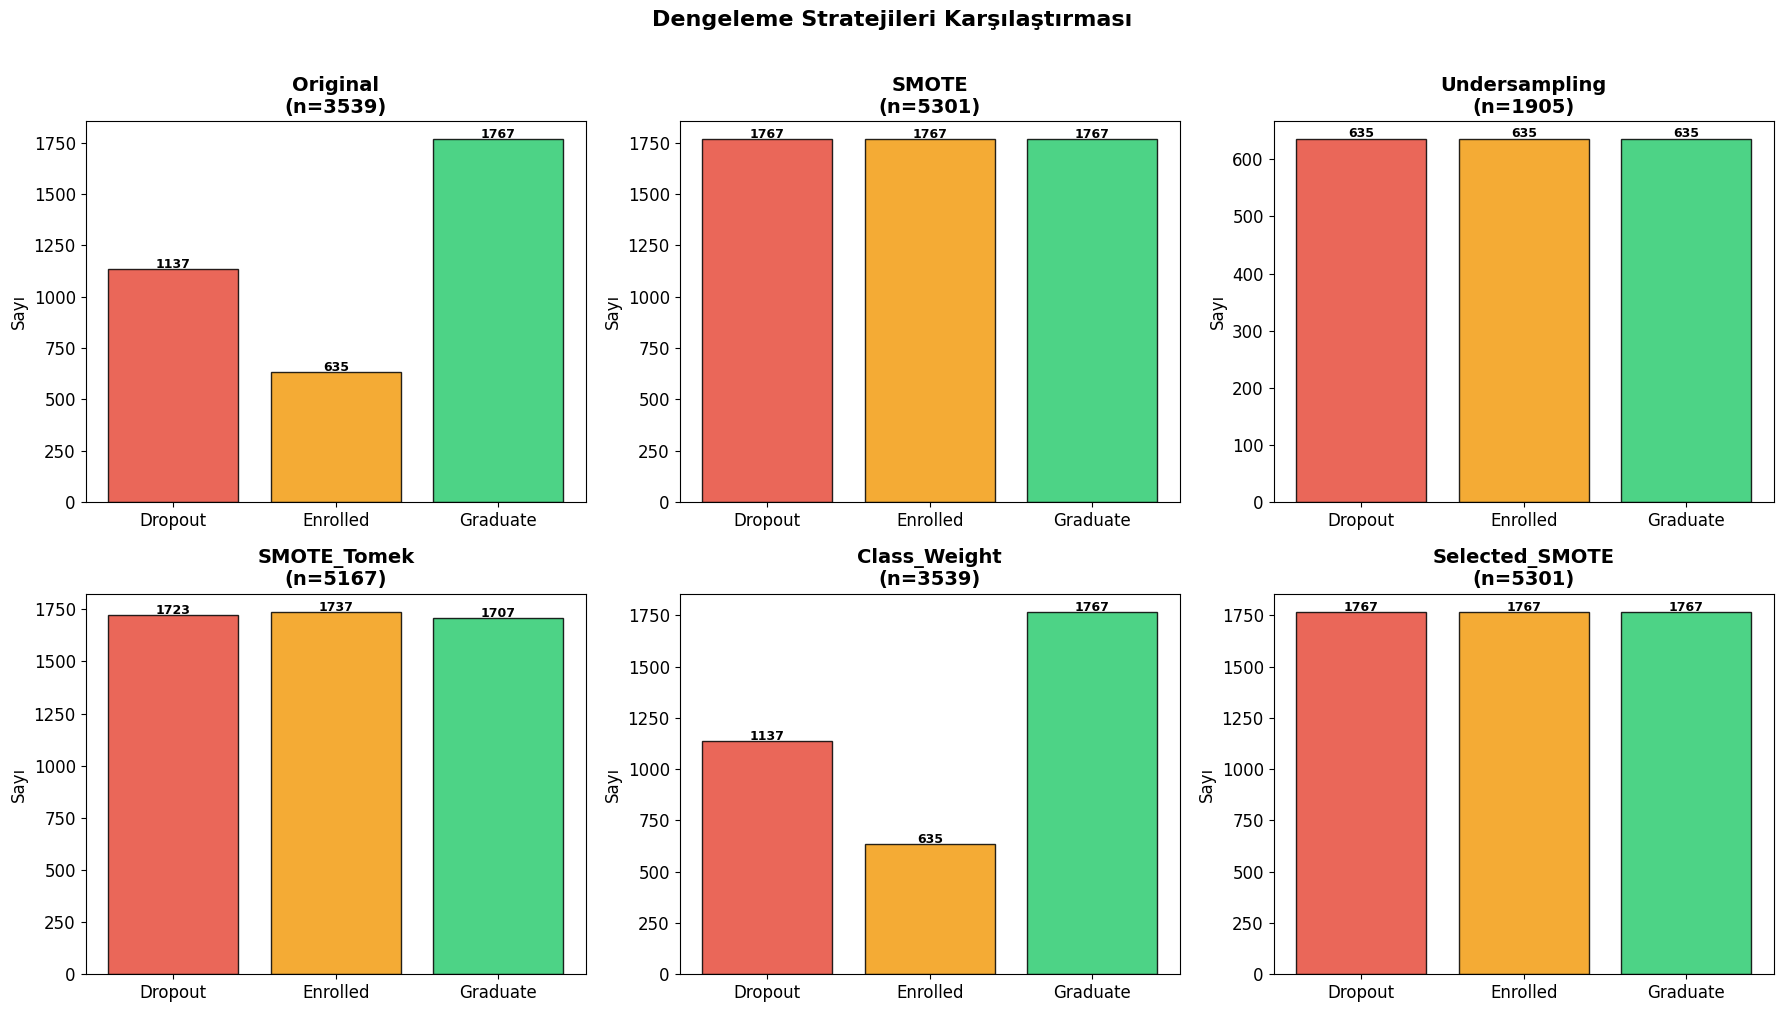


DENEY TASARIMI (Makale Tablosu)
Deney      Öznitelik Seti     Dengeleme            Train (n)    Test (n)
----------------------------------------------------------------------
Exp-1      Full (44)          Orijinal             3539         885
Exp-2      Full (44)          SMOTE                5301         885
Exp-3      Full (44)          Undersampling        1905         885
Exp-4      Full (44)          SMOTE+Tomek          5167         885
Exp-5      Full (44)          Class Weight         3539         885
Exp-6      Selected (26)      SMOTE                5301         885

✅ HÜCRE 3 TAMAMLANDI


In [ ]:
# =============================================================================
# HÜCRE 3: VERİ BÖLME VE DENGELEME STRATEJİLERİ
# =============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold

print("=" * 70)
print("AŞAMA 3: VERİ BÖLME VE DENGELEME STRATEJİLERİ")
print("=" * 70)

# --- 3.1 Train / Test Split ---
y = df_processed['Target_encoded'].copy()
X_full = df_processed[features_full].copy()
X_selected = df_processed[features_selected].copy()

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train_selected = X_train_full[features_selected].copy()
X_test_selected = X_test_full[features_selected].copy()

print(f"\nFull Features:     Train={X_train_full.shape}, Test={X_test_full.shape}")
print(f"Selected Features: Train={X_train_selected.shape}, Test={X_test_selected.shape}")

# Sınıf dağılımları
print(f"\nSınıf dağılımları:")
for name, data in [('Tüm Veri', y), ('Train', y_train), ('Test', y_test)]:
    counts = data.value_counts().sort_index()
    dist = ' | '.join([f"{le.classes_[i]}: {counts[i]} (%{counts[i]/len(data)*100:.1f})"
                       for i in range(len(le.classes_))])
    print(f"  {name:10s}: {dist}")

# --- 3.2 Cross-Validation Tanımı ---
cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# --- 3.3 Dengeleme Senaryoları ---
# ÖNEMLİ: SMOTE, CV pipeline'ı İÇİNDE uygulanacak (data leakage önleme)
# Burada sadece final eğitim için SMOTE versiyonlarını hazırlıyoruz
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote_full, y_train_smote = smote.fit_resample(X_train_full, y_train)

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under_full, y_train_under = rus.fit_resample(X_train_full, y_train)

smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_train_st_full, y_train_st = smote_tomek.fit_resample(X_train_full, y_train)

# Selected + SMOTE
X_train_smote_sel, y_train_smote_sel = smote.fit_resample(X_train_selected, y_train)

print("\n" + "-" * 50)
print("DENGELEME STRATEJİLERİ SONUÇLARI")
print("-" * 50)

strategies_info = {
    'Original':       {'X': X_train_full,       'y': y_train,       'desc': 'Dengesiz orijinal'},
    'SMOTE':          {'X': X_train_smote_full,  'y': y_train_smote, 'desc': 'SMOTE'},
    'Undersampling':  {'X': X_train_under_full,  'y': y_train_under, 'desc': 'Random Undersampling'},
    'SMOTE_Tomek':    {'X': X_train_st_full,     'y': y_train_st,    'desc': 'SMOTE + Tomek Links'},
    'Class_Weight':   {'X': X_train_full,        'y': y_train,       'desc': 'class_weight=balanced'},
    'Selected_SMOTE': {'X': X_train_smote_sel,   'y': y_train_smote_sel, 'desc': 'Selected (24) + SMOTE'},
}

for name, info in strategies_info.items():
    dist = dict(Counter(info['y']))
    print(f"  {name:18s}: n={len(info['y']):5d} | {dist} | {info['desc']}")

# --- 3.4 Dengeleme Görselleştirmesi ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71']

for idx, (name, info) in enumerate(strategies_info.items()):
    ax = axes_flat[idx]
    counts = pd.Series(info['y']).value_counts().sort_index()
    ax.bar(le.classes_, [counts.get(i, 0) for i in range(3)],
           color=colors_bar, edgecolor='black', alpha=0.85)
    ax.set_title(f'{name}\n(n={len(info["y"])})', fontweight='bold')
    ax.set_ylabel('Sayı')
    for i, v in enumerate([counts.get(j, 0) for j in range(3)]):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Dengeleme Stratejileri Karşılaştırması', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_balancing_strategies.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 3.5 Deney Tasarımı Özet Tablosu ---
print("\n" + "=" * 70)
print("DENEY TASARIMI (Makale Tablosu)")
print("=" * 70)
print(f"{'Deney':<10} {'Öznitelik Seti':<18} {'Dengeleme':<20} {'Train (n)':<12} {'Test (n)'}")
print("-" * 70)
experiments = [
    ('Exp-1', f'Full ({len(features_full)})', 'Orijinal', len(y_train), len(y_test)),
    ('Exp-2', f'Full ({len(features_full)})', 'SMOTE', len(y_train_smote), len(y_test)),
    ('Exp-3', f'Full ({len(features_full)})', 'Undersampling', len(y_train_under), len(y_test)),
    ('Exp-4', f'Full ({len(features_full)})', 'SMOTE+Tomek', len(y_train_st), len(y_test)),
    ('Exp-5', f'Full ({len(features_full)})', 'Class Weight', len(y_train), len(y_test)),
    ('Exp-6', f'Selected ({len(features_selected)})', 'SMOTE', len(y_train_smote_sel), len(y_test)),
]
for exp in experiments:
    print(f"{exp[0]:<10} {exp[1]:<18} {exp[2]:<20} {exp[3]:<12} {exp[4]}")

print("\n✅ HÜCRE 3 TAMAMLANDI")


**HÜCRE 4: MODEL EĞİTİMİ**

AŞAMA 4: MODEL EĞİTİMİ
13 model tanımlandı (SMOTE pipeline içinde).

BASELINE CV (5-Fold, SMOTE pipeline içinde → data leakage YOK)
  Logistic_Regression... OK (4s) | Acc:0.7536 | F1:0.6953 | Gap:0.0119
  kNN... OK (1s) | Acc:0.6832 | F1:0.6408 | Gap:0.1407
  Linear_SVM... OK (35s) | Acc:0.7542 | F1:0.6974 | Gap:0.0127
  RBF_SVM... OK (25s) | Acc:0.7624 | F1:0.7112 | Gap:0.0858
  MLP... OK (5s) | Acc:0.7491 | F1:0.6975 | Gap:0.0985
  Naive_Bayes... OK (0s) | Acc:0.7324 | F1:0.6670 | Gap:0.0044
  Decision_Tree... OK (1s) | Acc:0.6827 | F1:0.6278 | Gap:0.3173
  Random_Forest... OK (10s) | Acc:0.7632 | F1:0.7058 | Gap:0.2368
  Extra_Trees... OK (6s) | Acc:0.7694 | F1:0.7118 | Gap:0.2306
  AdaBoost... OK (10s) | Acc:0.7423 | F1:0.6981 | Gap:0.0119
  Gradient_Boosting... OK (56s) | Acc:0.7731 | F1:0.7170 | Gap:0.1120
  XGBoost... OK (7s) | Acc:0.7708 | F1:0.7088 | Gap:0.2292
  LightGBM... OK (35s) | Acc:0.7771 | F1:0.7182 | Gap:0.2229

Baseline Sıralama (F1-macro):
   1. LightGBM           

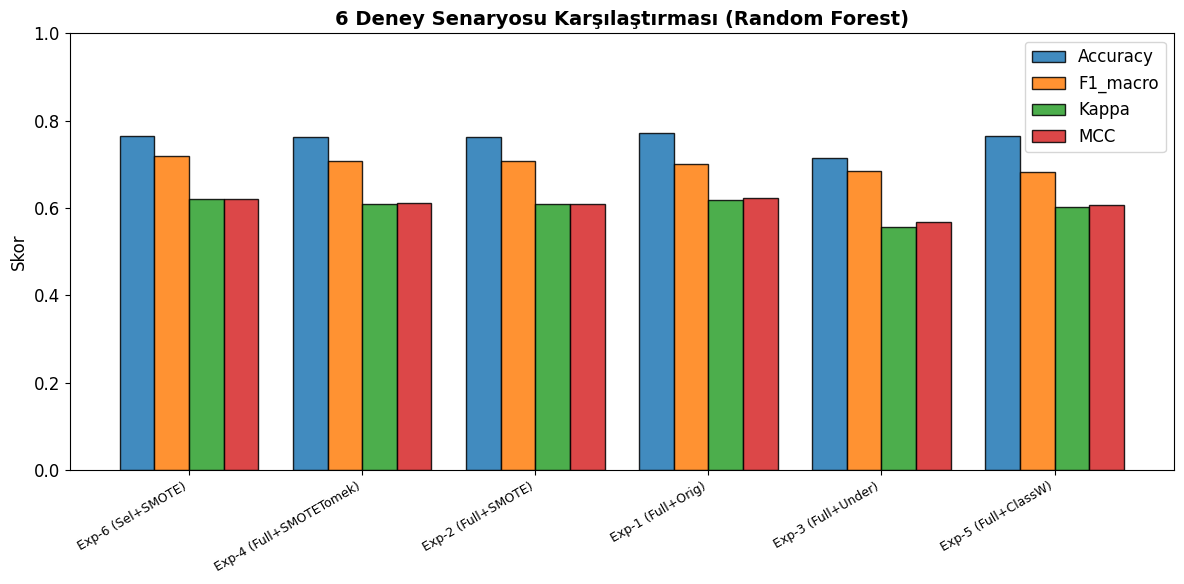

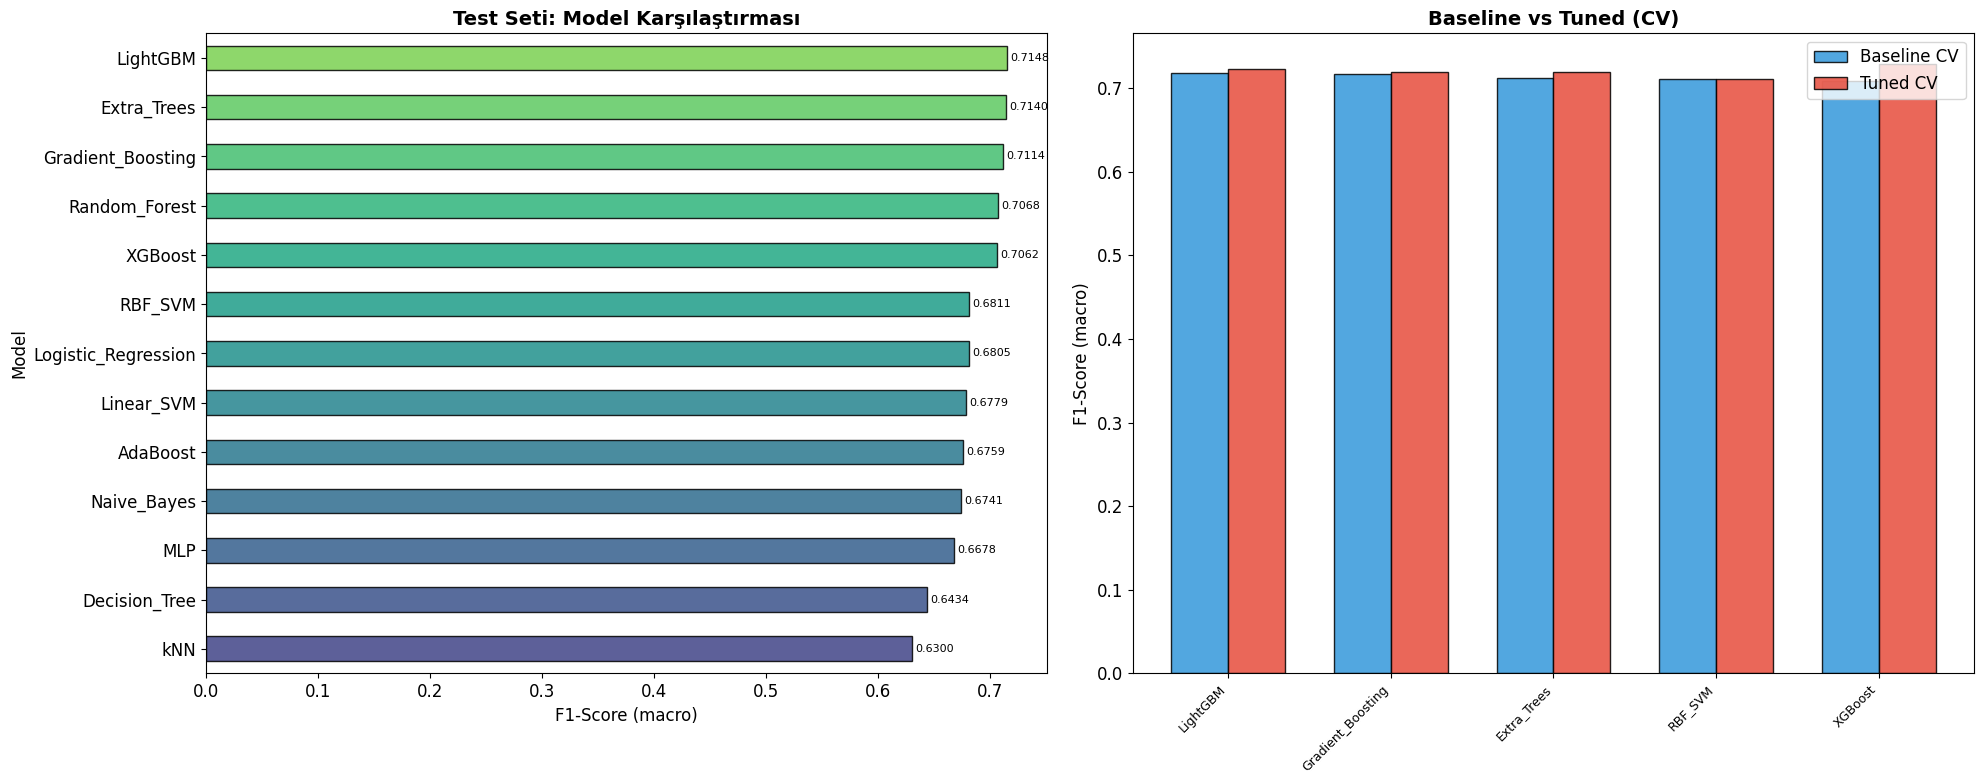


✅ HÜCRE 4 TAMAMLANDI


In [ ]:
# =============================================================================
# HÜCRE 4: MODEL EĞİTİMİ
# =============================================================================
# ÖNEMLİ: SMOTE, imblearn Pipeline içinde uygulanarak data leakage önleniyor.
# CV sırasında her fold'da SMOTE ayrı ayrı uygulanır.
# =============================================================================
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              cohen_kappa_score, matthews_corrcoef, log_loss,
                              roc_auc_score, make_scorer)
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import lightgbm as lgb

print("=" * 70)
print("AŞAMA 4: MODEL EĞİTİMİ")
print("=" * 70)

# --- 4.1 Model Tanımları (SMOTE pipeline İÇİNDE) ---
# SMOTE her CV fold'unda otomatik uygulanacak → data leakage YOK

smote_step = SMOTE(random_state=RANDOM_STATE)

models_pipeline = {
    'Logistic_Regression': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, multi_class='multinomial'))
    ]),
    'kNN': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Linear_SVM': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='linear', probability=True, random_state=RANDOM_STATE))
    ]),
    'RBF_SVM': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
    ]),
    'MLP': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(max_iter=1000, random_state=RANDOM_STATE, early_stopping=True))
    ]),
    'Naive_Bayes': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', GaussianNB())
    ]),
    'Decision_Tree': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    'Random_Forest': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Extra_Trees': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'AdaBoost': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE, algorithm='SAMME'))
    ]),
    'Gradient_Boosting': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ]),
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                   eval_metric='mlogloss', verbosity=0, n_jobs=-1))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1))
    ]),
}

print(f"{len(models_pipeline)} model tanımlandı (SMOTE pipeline içinde).\n")

# --- 4.2 Baseline CV (ORİJİNAL veri üzerinde, SMOTE pipeline içinde) ---
print("=" * 70)
print("BASELINE CV (5-Fold, SMOTE pipeline içinde → data leakage YOK)")
print("=" * 70)

scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro',
           'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

baseline_results = {}

for name, model in models_pipeline.items():
    start = time.time()
    print(f"  {name}...", end=" ", flush=True)
    try:
        cv_res = cross_validate(
            model, X_train_full, y_train,  # ORİJİNAL (dengesiz) veri
            cv=cv_5, scoring=scoring, return_train_score=True, n_jobs=-1
        )
        elapsed = time.time() - start
        baseline_results[name] = {
            'cv_acc': cv_res['test_accuracy'].mean(),
            'cv_acc_std': cv_res['test_accuracy'].std(),
            'cv_f1': cv_res['test_f1_macro'].mean(),
            'cv_f1_std': cv_res['test_f1_macro'].std(),
            'cv_prec': cv_res['test_precision_macro'].mean(),
            'cv_rec': cv_res['test_recall_macro'].mean(),
            'train_acc': cv_res['train_accuracy'].mean(),
            'fold_scores': cv_res['test_f1_macro'],
            'time': elapsed
        }
        gap = baseline_results[name]['train_acc'] - baseline_results[name]['cv_acc']
        print(f"OK ({elapsed:.0f}s) | Acc:{baseline_results[name]['cv_acc']:.4f} "
              f"| F1:{baseline_results[name]['cv_f1']:.4f} | Gap:{gap:.4f}")
    except Exception as e:
        print(f"HATA: {e}")
        baseline_results[name] = None

valid = {k: v for k, v in baseline_results.items() if v is not None}
ranked = sorted(valid.items(), key=lambda x: x[1]['cv_f1'], reverse=True)

print(f"\nBaseline Sıralama (F1-macro):")
for i, (n, r) in enumerate(ranked, 1):
    print(f"  {i:2d}. {n:25s} F1={r['cv_f1']:.4f} ± {r['cv_f1_std']:.4f}")

# --- 4.3 Hiperparametre Optimizasyonu (Top 5) ---
print("\n" + "=" * 70)
print("HİPERPARAMETRE OPTİMİZASYONU (Top 5 Model)")
print("=" * 70)

top5_names = [n for n, _ in ranked[:5]]

param_grids = {
    'Random_Forest': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__max_depth': [None, 10, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    },
    'Extra_Trees': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__max_depth': [None, 10, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [3, 5, 7, 10],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [-1, 10, 20],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__num_leaves': [31, 50, 80],
        'clf__subsample': [0.8, 1.0]
    },
    'Gradient_Boosting': {
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__subsample': [0.8, 1.0]
    },
    'Logistic_Regression': {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__solver': ['lbfgs', 'saga']
    },
    'RBF_SVM': {
        'clf__C': [0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.01, 0.001]
    },
    'MLP': {
        'clf__hidden_layer_sizes': [(64,32), (128,64), (128,64,32)],
        'clf__alpha': [0.0001, 0.001, 0.01],
        'clf__learning_rate': ['constant', 'adaptive']
    },
}

tuned_results = {}
best_estimators = {}

for name in top5_names:
    if name not in param_grids:
        print(f"  {name}: Param grid yok, atlanıyor.")
        continue

    start = time.time()
    print(f"  {name}...", end=" ", flush=True)
    grid = param_grids[name]
    total_comb = 1
    for v in grid.values():
        total_comb *= len(v)
    n_iter = min(50, total_comb)

    search = RandomizedSearchCV(
        models_pipeline[name], grid, n_iter=n_iter, cv=cv_5,
        scoring='f1_macro', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    try:
        search.fit(X_train_full, y_train)  # ORİJİNAL veri (SMOTE pipeline içinde)
        elapsed = time.time() - start
        bl_f1 = valid[name]['cv_f1']
        tuned_f1 = search.best_score_
        imp = tuned_f1 - bl_f1
        tuned_results[name] = {
            'best_score': tuned_f1, 'best_params': search.best_params_,
            'baseline_f1': bl_f1, 'improvement': imp
        }
        best_estimators[name] = search.best_estimator_
        arrow = '↑' if imp > 0 else '↓'
        print(f"OK ({elapsed:.0f}s) [{n_iter}/{total_comb}] | "
              f"F1: {bl_f1:.4f} → {tuned_f1:.4f} ({arrow}{abs(imp):.4f})")
        print(f"         En iyi parametreler: {search.best_params_}")
    except Exception as e:
        print(f"HATA: {e}")

# --- 4.4 Final Modelleri Hazırla ---
print("\n" + "=" * 70)
print("FİNAL MODELLERİ - Tüm Eğitim Verisi ile Eğitim")
print("=" * 70)

# Final eğitimi: SMOTE uygulanmış tam eğitim seti üzerinde
final_models = {}
for name in models_pipeline.keys():
    if name in best_estimators:
        # Tuned model → SMOTE'suz versiyonunu oluştur (final eğitim için)
        est = best_estimators[name]
        # Pipeline'dan clf'yi çıkar
        clf = est.named_steps['clf']
        if 'scaler' in est.named_steps:
            from sklearn.pipeline import Pipeline as SkPipeline
            final_model = SkPipeline([('scaler', StandardScaler()), ('clf', clone(clf))])
        else:
            final_model = clone(clf)
    else:
        # Baseline model → pipeline'dan clf çıkar
        pipe = models_pipeline[name]
        clf = pipe.named_steps['clf']
        if 'scaler' in pipe.named_steps:
            from sklearn.pipeline import Pipeline as SkPipeline
            final_model = SkPipeline([('scaler', StandardScaler()), ('clf', clone(clf))])
        else:
            final_model = clone(clf)

    final_model.fit(X_train_smote_full, y_train_smote)
    final_models[name] = final_model
    print(f"  ✓ {name}")

# --- 4.5 Test Tahminleri ---
test_predictions = {}
test_probabilities = {}
for name, model in final_models.items():
    test_predictions[name] = model.predict(X_test_full)
    try:
        test_probabilities[name] = model.predict_proba(X_test_full)
    except:
        test_probabilities[name] = None

# --- 4.6 Ana Metrik Tablosu ---
print("\n" + "=" * 70)
print("TEST SETİ SONUÇLARI (Exp-2: Full + SMOTE)")
print("=" * 70)

metrics_rows = []
for name in final_models.keys():
    yp = test_predictions[name]
    ypr = test_probabilities.get(name)
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision_macro': precision_score(y_test, yp, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_test, yp, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test, yp, average='macro', zero_division=0),
        'F1_weighted': f1_score(y_test, yp, average='weighted', zero_division=0),
        'Kappa': cohen_kappa_score(y_test, yp),
        'MCC': matthews_corrcoef(y_test, yp),
    }
    if ypr is not None:
        try:
            row['ROC_AUC'] = roc_auc_score(y_test, ypr, multi_class='ovr', average='macro')
        except:
            row['ROC_AUC'] = None
    else:
        row['ROC_AUC'] = None
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('F1_macro', ascending=False)
print(metrics_df.to_string(float_format='%.4f'))

# Kaydet
metrics_df.to_csv(os.path.join(DATA_DIR, 'model_comparison_metrics.csv'))

# --- 4.7 Tüm 6 Senaryo Karşılaştırması (En İyi Model: RF) ---
print("\n" + "=" * 70)
print("TÜM 6 SENARYO KARŞILAŞTIRMASI (Random Forest)")
print("=" * 70)

# RF'nin tuned parametrelerini al
if 'Random_Forest' in best_estimators:
    rf_params = best_estimators['Random_Forest'].named_steps['clf'].get_params()
else:
    rf_params = {'n_estimators': 200, 'random_state': RANDOM_STATE}

scenario_results = {}
scenario_configs = {
    'Exp-1 (Full+Orig)':      (X_train_full, y_train, X_test_full, False),
    'Exp-2 (Full+SMOTE)':     (X_train_smote_full, y_train_smote, X_test_full, False),
    'Exp-3 (Full+Under)':     (X_train_under_full, y_train_under, X_test_full, False),
    'Exp-4 (Full+SMOTETomek)':(X_train_st_full, y_train_st, X_test_full, False),
    'Exp-5 (Full+ClassW)':    (X_train_full, y_train, X_test_full, True),
    'Exp-6 (Sel+SMOTE)':      (X_train_smote_sel, y_train_smote_sel, X_test_selected, False),
}

for exp_name, (X_tr, y_tr, X_te, use_cw) in scenario_configs.items():
    params = {k: v for k, v in rf_params.items() if k not in ['class_weight']}
    if use_cw:
        params['class_weight'] = 'balanced'
    rf_exp = RandomForestClassifier(**params)
    rf_exp.fit(X_tr, y_tr)
    yp = rf_exp.predict(X_te)
    scenario_results[exp_name] = {
        'Accuracy': accuracy_score(y_test, yp),
        'F1_macro': f1_score(y_test, yp, average='macro', zero_division=0),
        'Kappa': cohen_kappa_score(y_test, yp),
        'MCC': matthews_corrcoef(y_test, yp)
    }

scenario_df = pd.DataFrame(scenario_results).T
scenario_df = scenario_df.sort_values('F1_macro', ascending=False)
print(scenario_df.to_string(float_format='%.4f'))
scenario_df.to_csv(os.path.join(DATA_DIR, 'scenario_comparison.csv'))

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(scenario_df))
w = 0.2
for i, col in enumerate(['Accuracy', 'F1_macro', 'Kappa', 'MCC']):
    ax.bar(x + i*w, scenario_df[col], w, label=col, alpha=0.85, edgecolor='black')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(scenario_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Skor')
ax.set_title('6 Deney Senaryosu Karşılaştırması (Random Forest)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_scenario_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Baseline vs Tuned görsel
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Sol: Tüm modellerin test F1
test_f1 = metrics_df['F1_macro'].sort_values(ascending=True)
cmap = plt.cm.viridis(np.linspace(0.2, 0.8, len(test_f1)))
ax = axes[0]
test_f1.plot(kind='barh', ax=ax, color=cmap, edgecolor='black', alpha=0.85)
ax.set_xlabel('F1-Score (macro)')
ax.set_title('Test Seti: Model Karşılaştırması', fontweight='bold')
for i, (idx, v) in enumerate(test_f1.items()):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)

# Sağ: Baseline vs Tuned
if tuned_results:
    tuned_names = list(tuned_results.keys())
    bl_vals = [tuned_results[n]['baseline_f1'] for n in tuned_names]
    tu_vals = [tuned_results[n]['best_score'] for n in tuned_names]
    ax = axes[1]
    x = np.arange(len(tuned_names))
    w = 0.35
    ax.bar(x - w/2, bl_vals, w, label='Baseline CV', color='#3498db', edgecolor='black', alpha=0.85)
    ax.bar(x + w/2, tu_vals, w, label='Tuned CV', color='#e74c3c', edgecolor='black', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(tuned_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('F1-Score (macro)')
    ax.set_title('Baseline vs Tuned (CV)', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ HÜCRE 4 TAMAMLANDI")


**HÜCRE 5: MODEL DEĞERLENDİRME, SHAP ANALİZİ VE ABLASYON ÇALIŞMASI**

AŞAMA 5: MODEL DEĞERLENDİRME
En iyi model: LightGBM

--------------------------------------------------
5.1 SINIF BAZLI METRİKLER (En İyi 3 Model)
--------------------------------------------------

--- LightGBM ---
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.78       284
    Enrolled       0.49      0.54      0.51       159
    Graduate       0.84      0.87      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885


--- Extra_Trees ---
              precision    recall  f1-score   support

     Dropout       0.83      0.76      0.79       284
    Enrolled       0.48      0.53      0.50       159
    Graduate       0.84      0.86      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.76      0.77       885




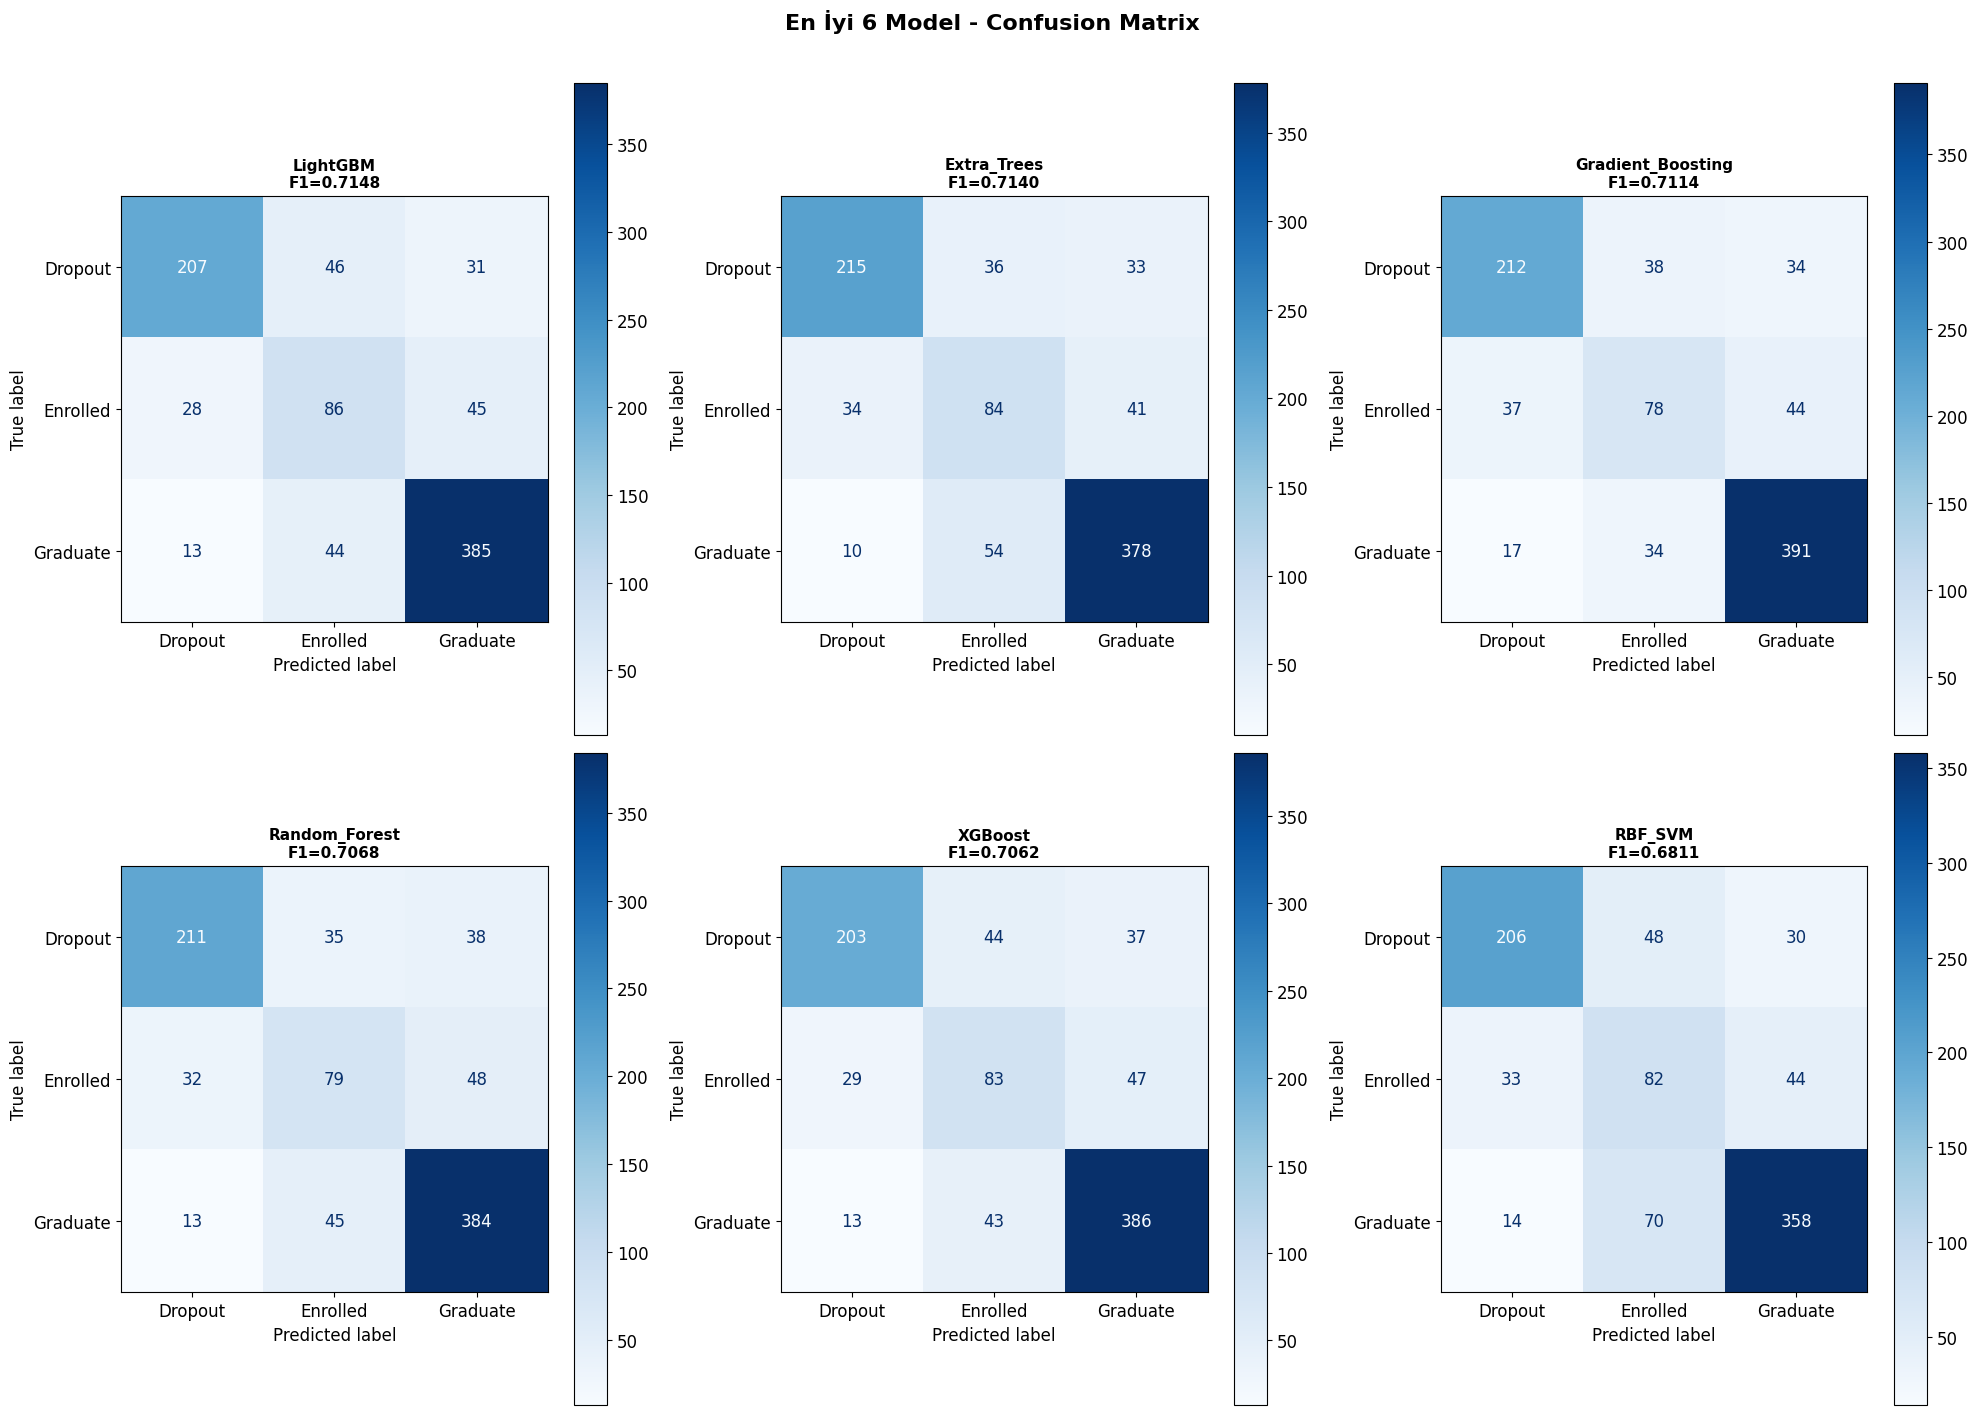

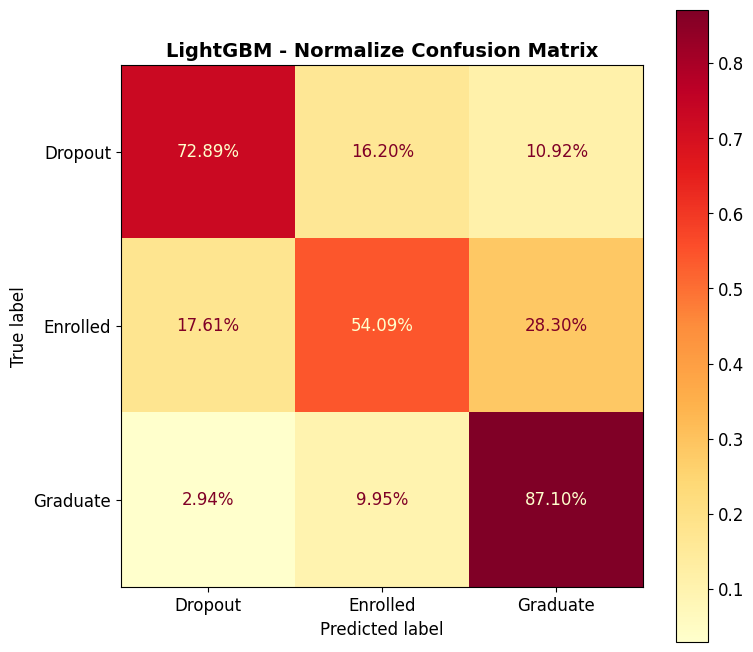


Hata Analizi (LightGBM):
  Dropout: Recall=0.7289 | Yanlış sınıflandırma: Enrolled: 46, Graduate: 31
  Enrolled: Recall=0.5409 | Yanlış sınıflandırma: Dropout: 28, Graduate: 45
  Graduate: Recall=0.8710 | Yanlış sınıflandırma: Dropout: 13, Enrolled: 44

5.3 ROC EĞRİLERİ


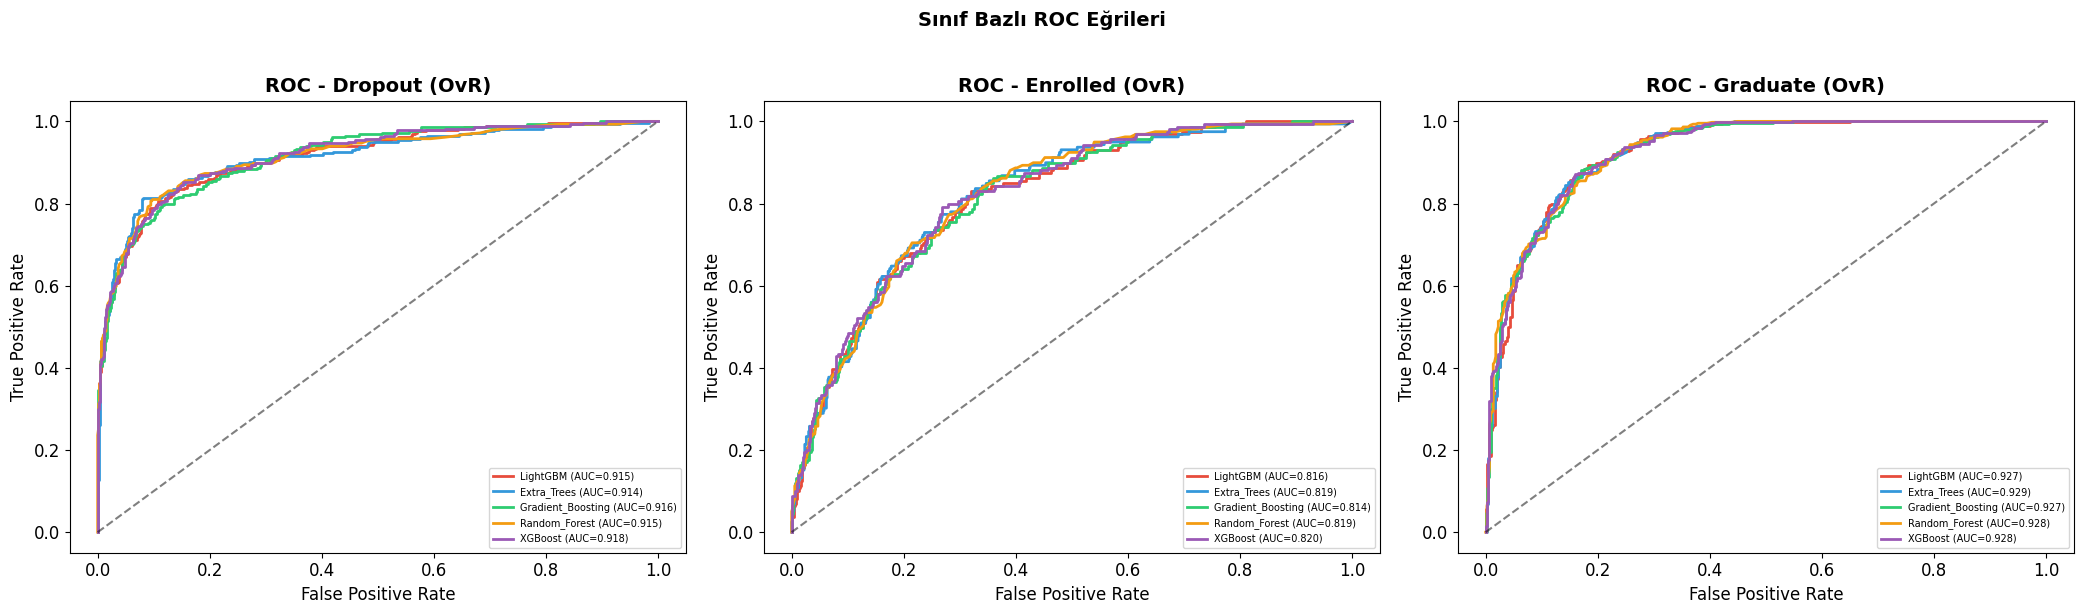


5.4 FEATURE IMPORTANCE


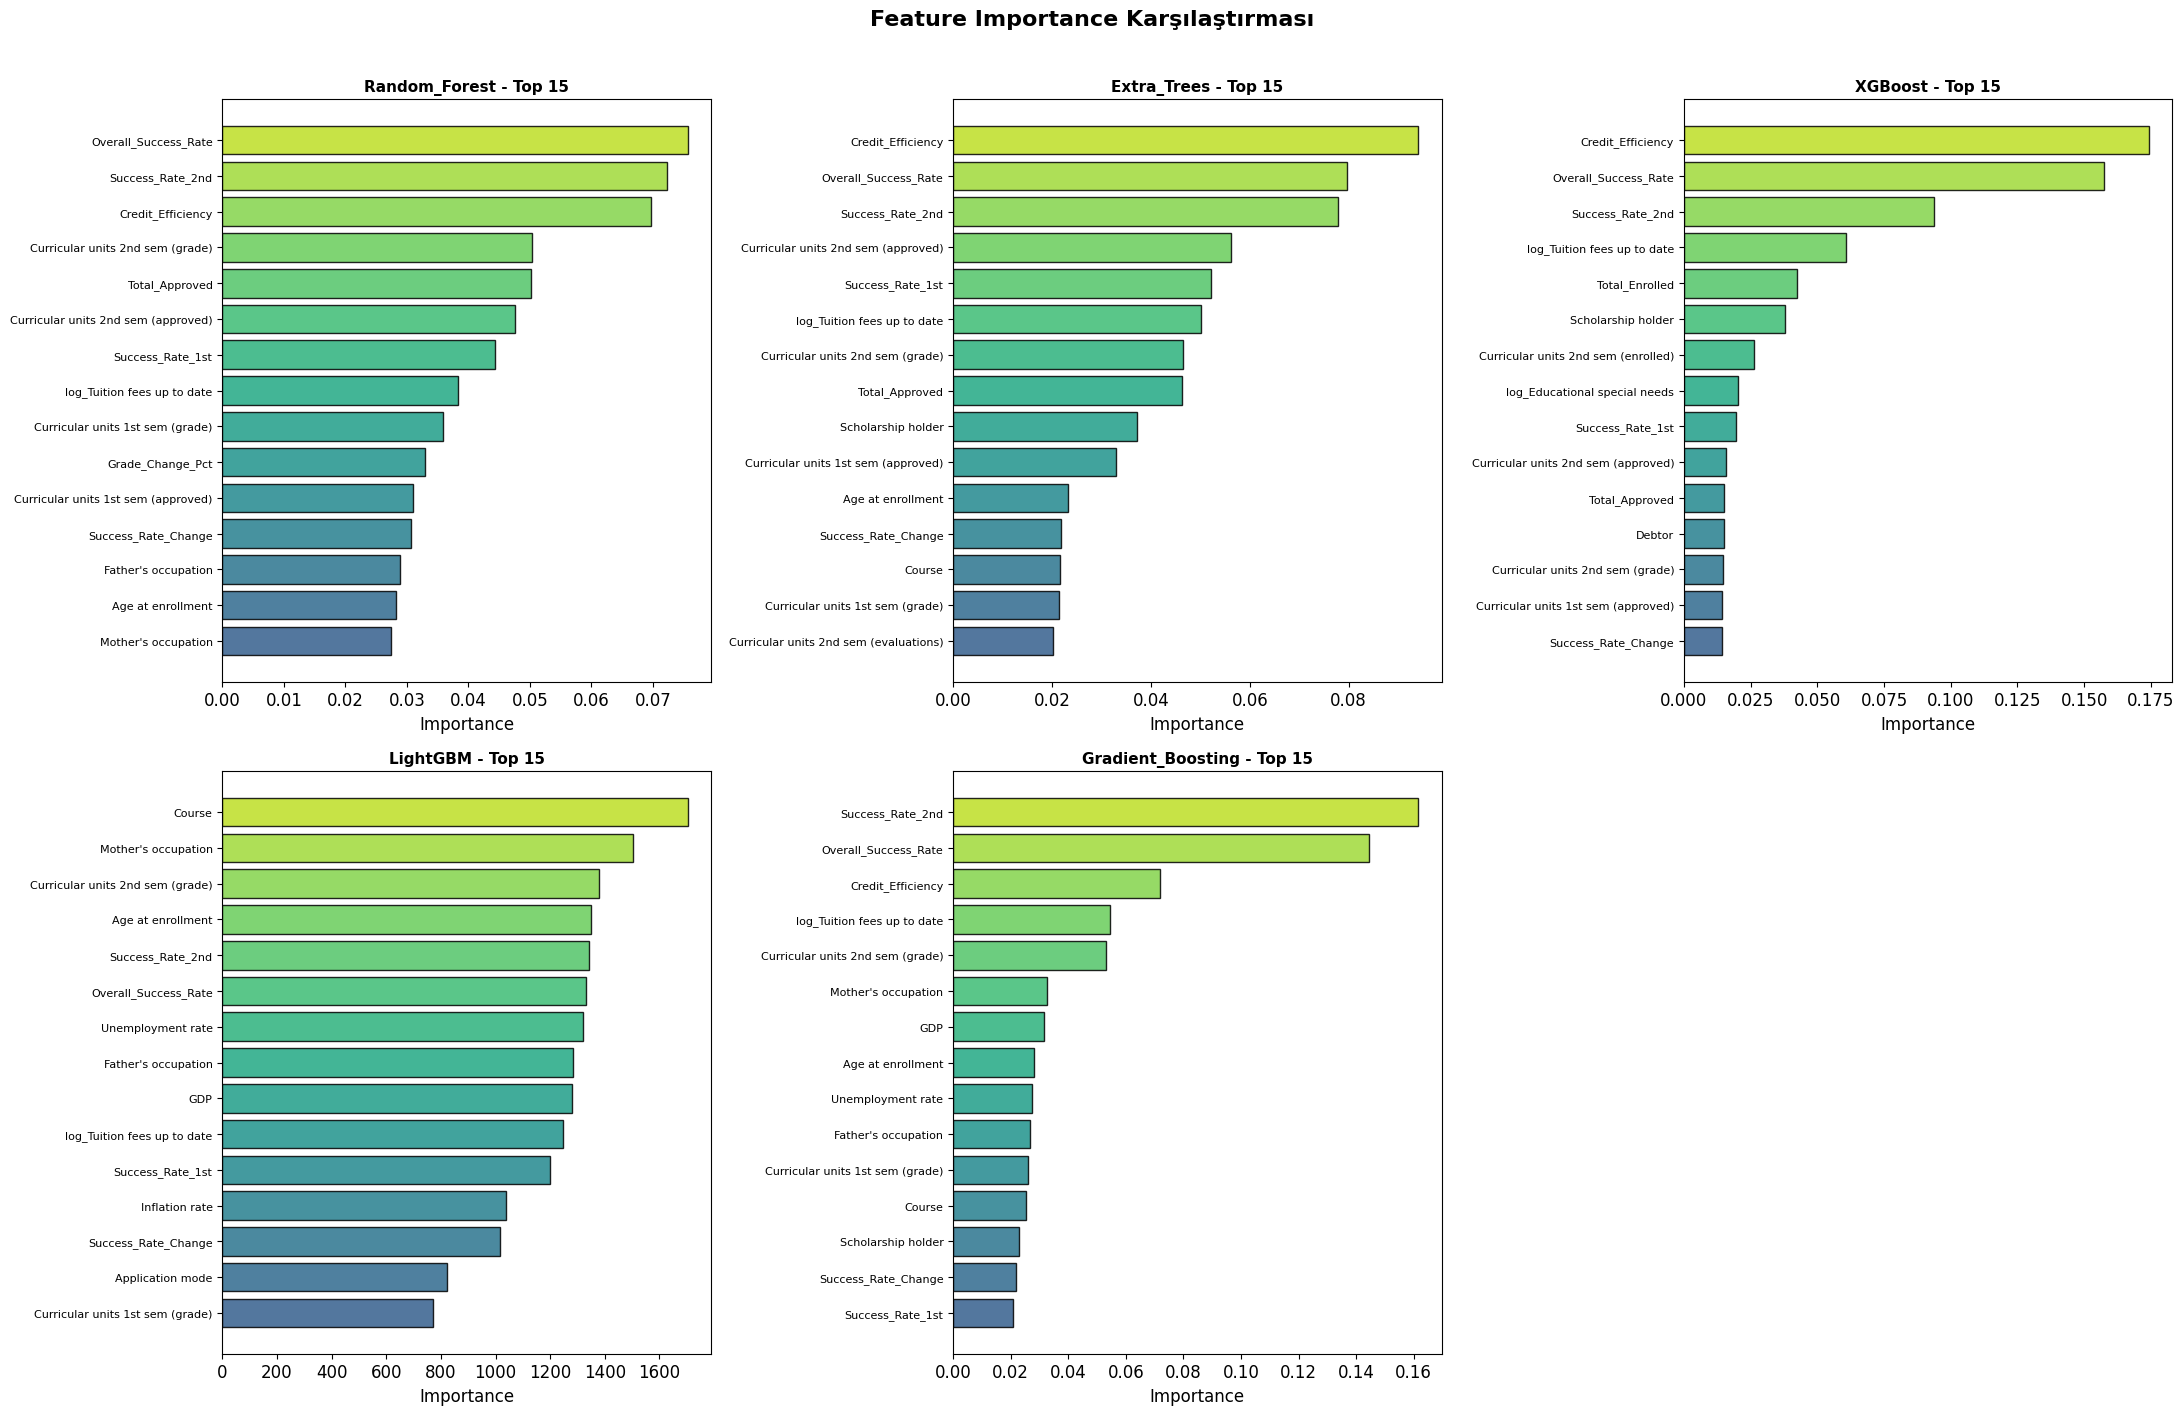


5.5 SHAP ANALİZİ
SHAP hesaplandı: 3 sınıf


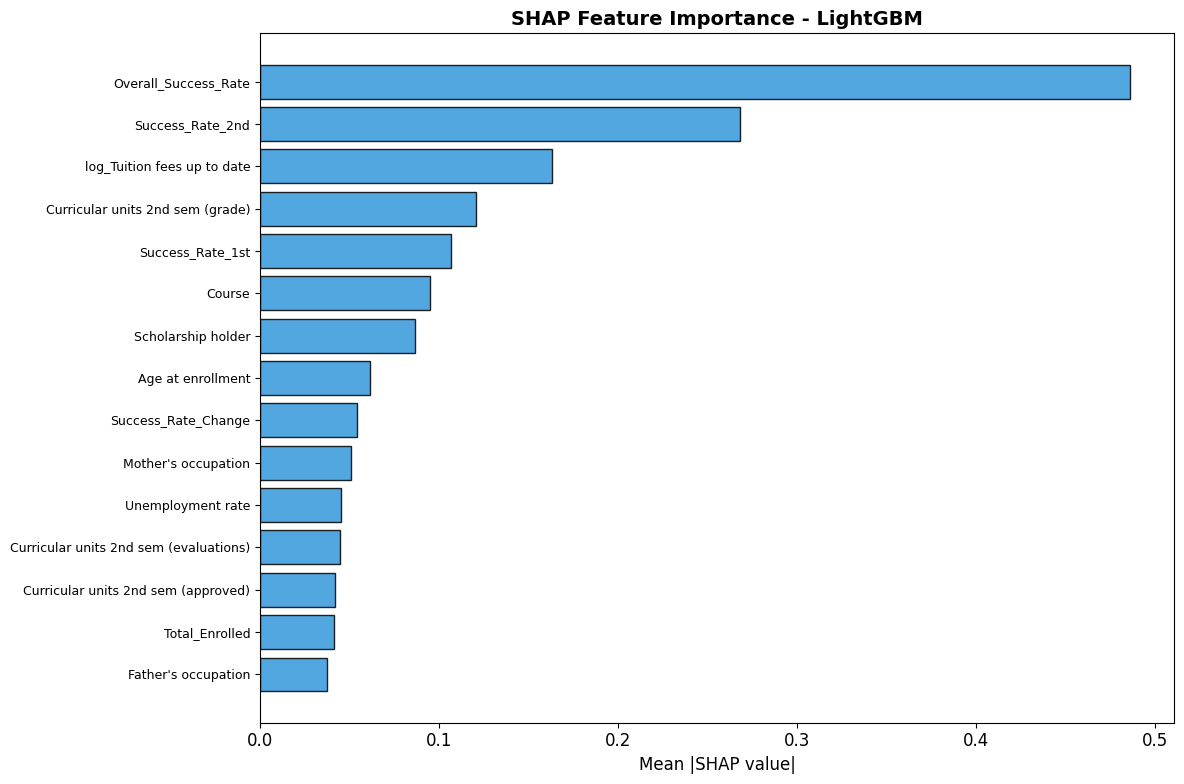

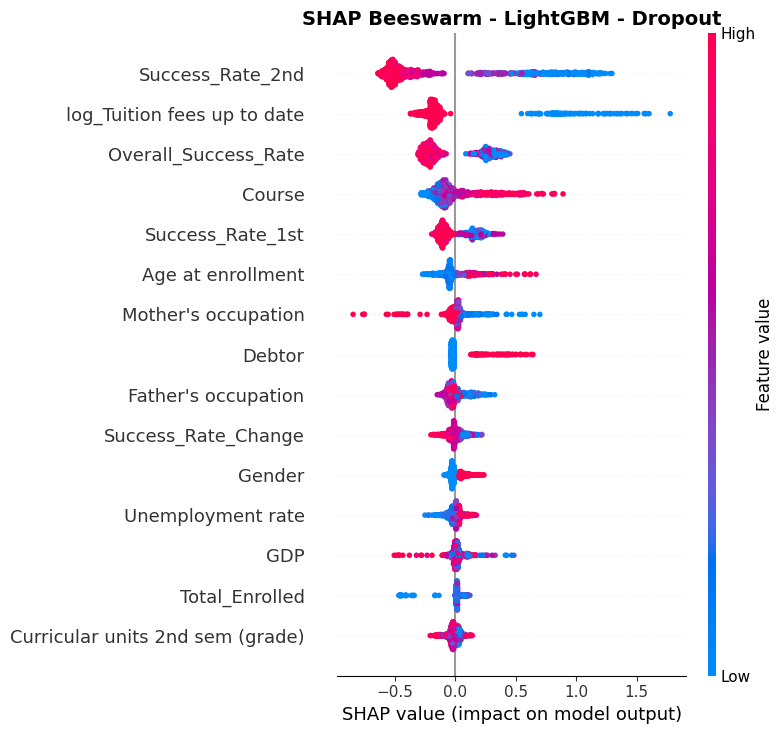

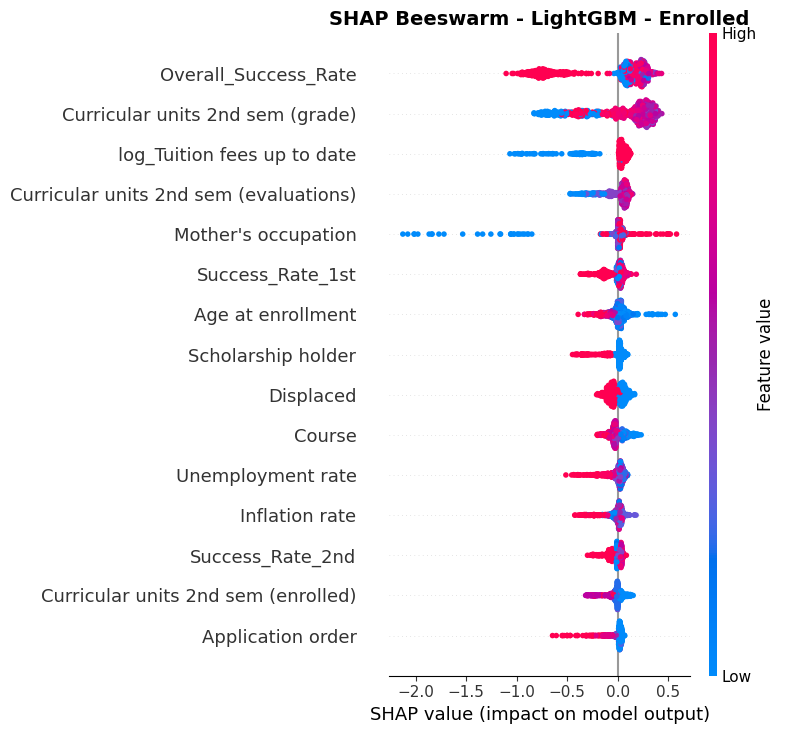

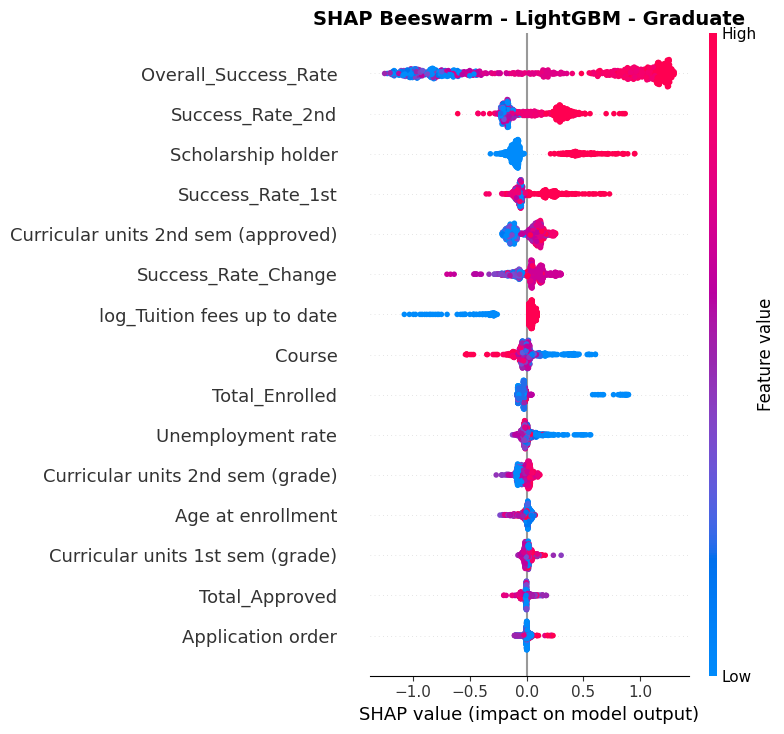

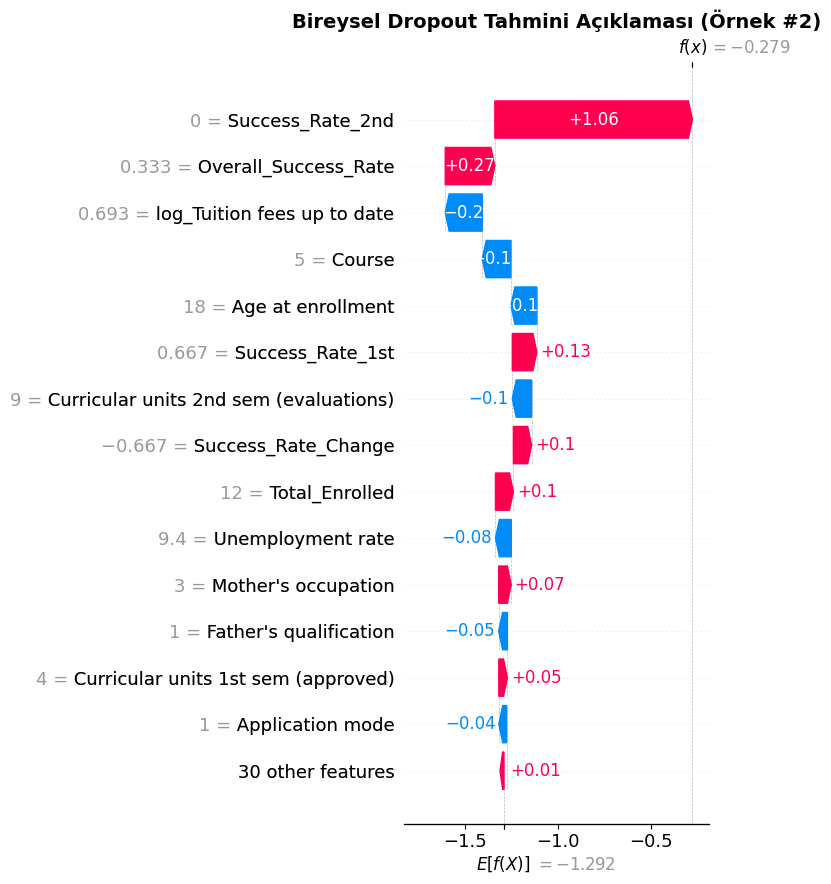

SHAP analizi tamamlandı.

5.6 ABLASYON ÇALIŞMASI (Özellik Mühendisliğinin Etkisi)
Full öznitelik seti: 44 öznitelik
Orijinal öznitelikler (türetilmişler hariç): 34 öznitelik
Türetilen öznitelikler: 9 öznitelik

--- ABLASYON SONUÇLARI ---
                                Accuracy  F1_macro    MCC  n_features
Öznitelik Mühendisliği OLMADAN    0.7559    0.7030 0.6038     34.0000
Öznitelik Mühendisliği İLE        0.7661    0.7148 0.6204     44.0000

Özellik mühendisliğinin F1 katkısı: +0.0118 (+1.18%)

✅ HÜCRE 5 TAMAMLANDI


In [ ]:
# =============================================================================
# HÜCRE 5: MODEL DEĞERLENDİRME, SHAP ANALİZİ VE ABLASYON ÇALIŞMASI
# =============================================================================
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

print("=" * 70)
print("AŞAMA 5: MODEL DEĞERLENDİRME")
print("=" * 70)

class_names = le.classes_
n_classes = len(class_names)
best_model_name = metrics_df.index[0]
print(f"En iyi model: {best_model_name}")

# --- 5.1 Sınıf Bazlı Classification Report ---
print("\n" + "-" * 50)
print("5.1 SINIF BAZLI METRİKLER (En İyi 3 Model)")
print("-" * 50)

top3 = metrics_df.head(3).index.tolist()
per_class_data = []
for name in top3:
    print(f"\n--- {name} ---")
    report = classification_report(y_test, test_predictions[name],
                                   target_names=class_names, output_dict=True)
    print(classification_report(y_test, test_predictions[name], target_names=class_names))
    for cls in class_names:
        per_class_data.append({
            'Model': name, 'Sınıf': cls,
            'Precision': report[cls]['precision'],
            'Recall': report[cls]['recall'],
            'F1': report[cls]['f1-score'],
            'Support': report[cls]['support']
        })

per_class_df = pd.DataFrame(per_class_data)
per_class_df.to_csv(os.path.join(DATA_DIR, 'per_class_metrics.csv'), index=False)

# --- 5.2 Confusion Matrix (En İyi 6 Model) ---
print("\n5.2 CONFUSION MATRIX")
top6 = metrics_df.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
for idx, name in enumerate(top6):
    ax = axes.flatten()[idx]
    cm = confusion_matrix(y_test, test_predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
    f1_val = metrics_df.loc[name, 'F1_macro']
    ax.set_title(f'{name}\nF1={f1_val:.4f}', fontweight='bold', fontsize=11)

plt.suptitle('En İyi 6 Model - Confusion Matrix', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# Normalize edilmiş (en iyi model)
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, test_predictions[best_model_name])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=ax, cmap='YlOrRd', values_format='.2%')
ax.set_title(f'{best_model_name} - Normalize Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_confusion_matrix_normalized.png'), dpi=150, bbox_inches='tight')
plt.show()

# Hata analizi
print(f"\nHata Analizi ({best_model_name}):")
for i, cls in enumerate(class_names):
    recall = cm[i, i] / cm[i].sum()
    misclass = {class_names[j]: cm[i, j] for j in range(n_classes) if j != i and cm[i, j] > 0}
    misclass_str = ', '.join([f"{k}: {v}" for k, v in misclass.items()])
    print(f"  {cls}: Recall={recall:.4f} | Yanlış sınıflandırma: {misclass_str}")

# --- 5.3 ROC Eğrileri ---
print("\n5.3 ROC EĞRİLERİ")
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
top5_roc = [n for n in metrics_df.head(5).index if test_probabilities.get(n) is not None]
roc_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for cls_idx, cls_name in enumerate(class_names):
    ax = axes[cls_idx]
    for mdl_idx, name in enumerate(top5_roc):
        ypr = test_probabilities[name]
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], ypr[:, cls_idx])
        roc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=roc_colors[mdl_idx], linewidth=2,
                label=f'{name} (AUC={roc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC - {cls_name} (OvR)', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Sınıf Bazlı ROC Eğrileri', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '11_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 5.4 Feature Importance ---
print("\n5.4 FEATURE IMPORTANCE")
tree_names = [n for n in ['Random_Forest', 'Extra_Trees', 'XGBoost', 'LightGBM', 'Gradient_Boosting']
              if n in final_models]
feat_names = X_train_full.columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes_flat = axes.flatten()

for idx, name in enumerate(tree_names):
    ax = axes_flat[idx]
    model = final_models[name]
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'named_steps') and hasattr(model.named_steps.get('clf', None), 'feature_importances_'):
        imp = model.named_steps['clf'].feature_importances_
    else:
        continue

    top_idx = np.argsort(imp)[-15:]
    ax.barh(range(15), imp[top_idx], color=plt.cm.viridis(np.linspace(0.3, 0.9, 15)),
            edgecolor='black', alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels([feat_names[i] for i in top_idx], fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} - Top 15', fontweight='bold', fontsize=11)

for idx in range(len(tree_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Feature Importance Karşılaştırması', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '12_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 5.5 SHAP ANALİZİ ---
print("\n" + "=" * 70)
print("5.5 SHAP ANALİZİ")
print("=" * 70)

import shap

best_model = final_models[best_model_name]
# SHAP için clf'yi çıkar (pipeline ise)
if hasattr(best_model, 'named_steps') and 'clf' in best_model.named_steps:
    shap_model = best_model.named_steps['clf']
    if 'scaler' in best_model.named_steps:
        X_test_shap = pd.DataFrame(
            best_model.named_steps['scaler'].transform(X_test_full),
            columns=feat_names
        )
    else:
        X_test_shap = X_test_full
else:
    shap_model = best_model
    X_test_shap = X_test_full

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_shap)

# SHAP çıktı formatını kontrol et
if isinstance(shap_values, list):
    # Eski format: [class0_array, class1_array, class2_array]
    shap_per_class = shap_values
elif shap_values.ndim == 3:
    # Yeni format: (n_samples, n_features, n_classes)
    shap_per_class = [shap_values[:, :, i] for i in range(n_classes)]
else:
    shap_per_class = [shap_values]

print(f"SHAP hesaplandı: {len(shap_per_class)} sınıf")

# SHAP Bar Plot (ortalama)
plt.figure(figsize=(12, 8))
mean_abs = np.mean([np.abs(sv) for sv in shap_per_class], axis=0).mean(axis=0)
top_shap_idx = np.argsort(mean_abs)[-15:]
plt.barh(range(15), mean_abs[top_shap_idx], color='#3498db', edgecolor='black', alpha=0.85)
plt.yticks(range(15), [feat_names[i] for i in top_shap_idx], fontsize=9)
plt.xlabel('Mean |SHAP value|')
plt.title(f'SHAP Feature Importance - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '13_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

# Sınıf bazlı SHAP Beeswarm
for cls_idx, cls_name in enumerate(class_names):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_per_class[cls_idx], X_test_shap.values if hasattr(X_test_shap, 'values') else X_test_shap,
                      feature_names=feat_names, show=False, max_display=15)
    plt.title(f'SHAP Beeswarm - {best_model_name} - {cls_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'14_shap_beeswarm_{cls_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()

# SHAP Waterfall (bireysel Dropout tahmini)
dropout_indices = np.where(test_predictions[best_model_name] == target_mapping.get('Dropout', 0))[0]
if len(dropout_indices) > 0:
    sample_idx = dropout_indices[0]
    dropout_class_idx = target_mapping.get('Dropout', 0)

    plt.figure(figsize=(12, 8))
    shap_explanation = shap.Explanation(
        values=shap_per_class[dropout_class_idx][sample_idx],
        base_values=explainer.expected_value[dropout_class_idx] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_test_shap.iloc[sample_idx].values if hasattr(X_test_shap, 'iloc') else X_test_shap[sample_idx],
        feature_names=feat_names
    )
    shap.waterfall_plot(shap_explanation, show=False, max_display=15)
    plt.title(f'Bireysel Dropout Tahmini Açıklaması (Örnek #{sample_idx})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '15_shap_waterfall_dropout.png'), dpi=150, bbox_inches='tight')
    plt.show()

print("SHAP analizi tamamlandı.")

# --- 5.6 ABLASYON ÇALIŞMASI ---
print("\n" + "=" * 70)
print("5.6 ABLASYON ÇALIŞMASI (Özellik Mühendisliğinin Etkisi)")
print("=" * 70)

# Türetilen öznitelikler HARİÇ orijinal öznitelikler
# Ayrıca log dönüşümü yapılan orijinalleri de düşünmeliyiz
all_engineered = new_features + [f'log_{f}' for f in new_features]
original_features_only = [f for f in features_full if f not in all_engineered]

print(f"Full öznitelik seti: {len(features_full)} öznitelik")
print(f"Orijinal öznitelikler (türetilmişler hariç): {len(original_features_only)} öznitelik")
print(f"Türetilen öznitelikler: {len([f for f in features_full if f in new_features])} öznitelik")

# Orijinal özniteliklerle SMOTE + RF
X_train_orig_only = X_train_full[original_features_only]
X_test_orig_only = X_test_full[original_features_only]

smote_abl = SMOTE(random_state=RANDOM_STATE)
X_tr_abl, y_tr_abl = smote_abl.fit_resample(X_train_orig_only, y_train)

rf_abl = RandomForestClassifier(**{k: v for k, v in rf_params.items()
                                    if k not in ['class_weight', 'n_jobs']},
                                 n_jobs=-1)
rf_abl.fit(X_tr_abl, y_tr_abl)
y_pred_abl = rf_abl.predict(X_test_orig_only)

abl_results = {
    'Öznitelik Mühendisliği OLMADAN': {
        'Accuracy': accuracy_score(y_test, y_pred_abl),
        'F1_macro': f1_score(y_test, y_pred_abl, average='macro'),
        'MCC': matthews_corrcoef(y_test, y_pred_abl),
        'n_features': len(original_features_only)
    },
    'Öznitelik Mühendisliği İLE': {
        'Accuracy': accuracy_score(y_test, test_predictions[best_model_name]),
        'F1_macro': f1_score(y_test, test_predictions[best_model_name], average='macro'),
        'MCC': matthews_corrcoef(y_test, test_predictions[best_model_name]),
        'n_features': len(features_full)
    }
}

print("\n--- ABLASYON SONUÇLARI ---")
abl_df = pd.DataFrame(abl_results).T
print(abl_df.to_string(float_format='%.4f'))

improvement = (abl_results['Öznitelik Mühendisliği İLE']['F1_macro'] -
               abl_results['Öznitelik Mühendisliği OLMADAN']['F1_macro'])
print(f"\nÖzellik mühendisliğinin F1 katkısı: {improvement:+.4f} ({improvement*100:+.2f}%)")
abl_df.to_csv(os.path.join(DATA_DIR, 'ablation_study.csv'))

print("\n✅ HÜCRE 5 TAMAMLANDI")


**HÜCRE 6: İstatistiksel Testler, CV vs Test Karşılaştırması ve Özet Rapor**

AŞAMA 6: İSTATİSTİKSEL TESTLER VE ÖZET RAPOR

6.1 İSTATİSTİKSEL ANLAMLILIK TESTLERİ
--------------------------------------------------
NOT: CV skorları SMOTE-in-pipeline ile hesaplandı (data leakage YOK)

Sıralama (CV F1-macro):
   1. LightGBM                  F1=0.7182
   2. Gradient_Boosting         F1=0.7170
   3. Extra_Trees               F1=0.7118
   4. RBF_SVM                   F1=0.7112
   5. XGBoost                   F1=0.7088
   6. Random_Forest             F1=0.7058
   7. AdaBoost                  F1=0.6981
   8. MLP                       F1=0.6975
   9. Linear_SVM                F1=0.6974
  10. Logistic_Regression       F1=0.6953
  11. Naive_Bayes               F1=0.6670
  12. kNN                       F1=0.6408
  13. Decision_Tree             F1=0.6278

Friedman Testi:
  Chi-square: 41.0110
  p-değeri: 0.000049
  Sonuç: Modeller arası anlamlı fark VAR (p<0.05)

10-FOLD CV İLE İSTATİSTİKSEL KARŞILAŞTIRMA
(5-fold'da Wilcoxon'un min p-değeri=0.0625, yeterli güç yok)
(10-fold i

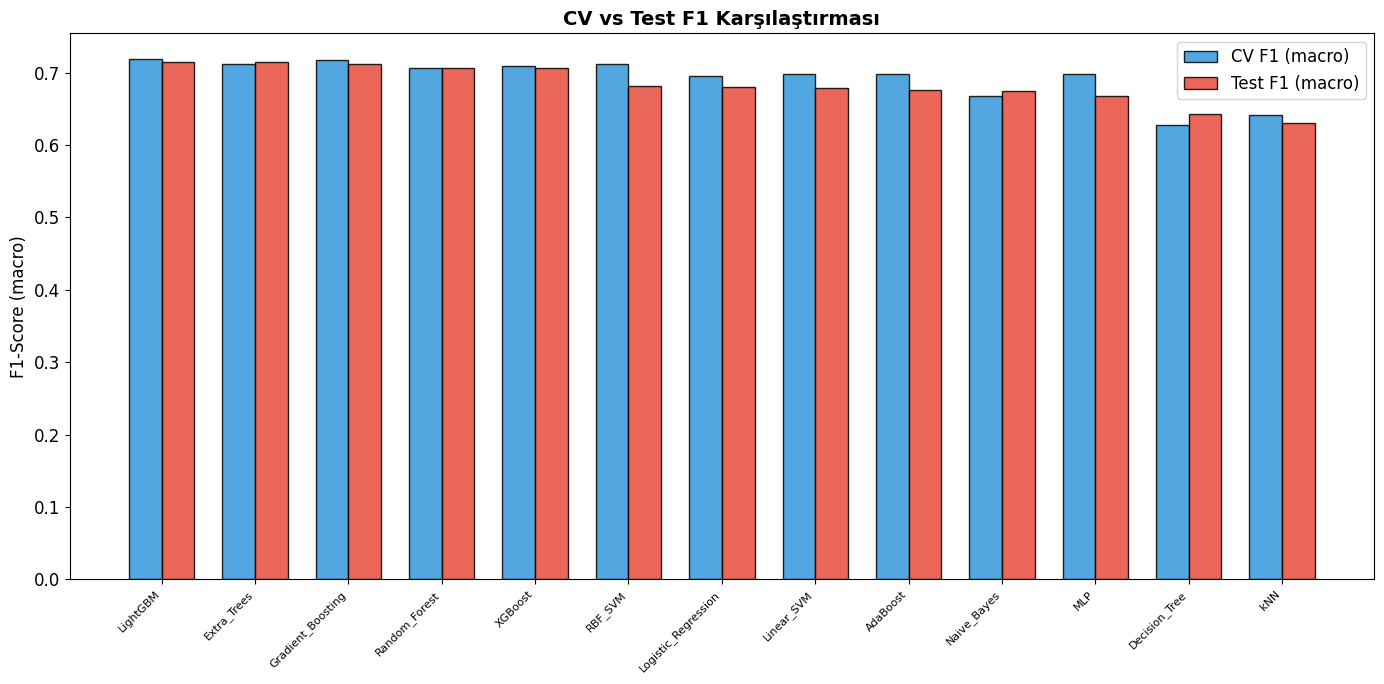


--------------------------------------------------
6.3 EN İYİ HİPERPARAMETRELER (Makale Tablosu)
--------------------------------------------------

LightGBM:
  CV F1: 0.7182 → 0.7230 (↑0.0048)
  subsample: 0.8
  num_leaves: 31
  n_estimators: 300
  max_depth: 10
  learning_rate: 0.01

Gradient_Boosting:
  CV F1: 0.7170 → 0.7186 (↑0.0015)
  subsample: 0.8
  n_estimators: 200
  max_depth: 7
  learning_rate: 0.05

Extra_Trees:
  CV F1: 0.7118 → 0.7185 (↑0.0067)
  n_estimators: 100
  min_samples_split: 5
  min_samples_leaf: 2
  max_depth: None

RBF_SVM:
  CV F1: 0.7112 → 0.7112 (↑0.0000)
  gamma: auto
  C: 1

XGBoost:
  CV F1: 0.7088 → 0.7289 (↑0.0201)
  subsample: 0.8
  n_estimators: 100
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.8

--------------------------------------------------
6.4 MODELLERİ KAYDET
--------------------------------------------------
  ✓ Logistic_Regression.pkl
  ✓ kNN.pkl
  ✓ Linear_SVM.pkl
  ✓ RBF_SVM.pkl
  ✓ MLP.pkl
  ✓ Naive_Bayes.pkl
  ✓ Decisio

In [ ]:
# =============================================================================
# HÜCRE 6 DÜZELTİLMİŞ VERSİYON
# =============================================================================
# ÖNCEKİ HÜCRE 6'YI SİLİN, BU KODU YENİ HÜCREYE YAPIŞTIRIN
# =============================================================================
from scipy.stats import friedmanchisquare, wilcoxon
import pickle

print("=" * 70)
print("AŞAMA 6: İSTATİSTİKSEL TESTLER VE ÖZET RAPOR")
print("=" * 70)

# --- 6.1 Friedman ve Wilcoxon Testleri ---
print("\n6.1 İSTATİSTİKSEL ANLAMLILIK TESTLERİ")
print("-" * 50)
print("NOT: CV skorları SMOTE-in-pipeline ile hesaplandı (data leakage YOK)")

cv_scores_dict = {}
for name, res in baseline_results.items():
    if res is not None and 'fold_scores' in res:
        cv_scores_dict[name] = res['fold_scores']

# ÖNEMLİ: F1 skoruna göre sırala (en iyi model ilk sıraya gelsin)
sorted_models = sorted(cv_scores_dict.keys(),
                       key=lambda n: cv_scores_dict[n].mean(), reverse=True)

scores_matrix = np.array([cv_scores_dict[n] for n in sorted_models])

print(f"\nSıralama (CV F1-macro):")
for i, n in enumerate(sorted_models):
    print(f"  {i+1:2d}. {n:25s} F1={cv_scores_dict[n].mean():.4f}")

if len(sorted_models) >= 3:
    stat, p_val = friedmanchisquare(*[scores_matrix[i] for i in range(len(sorted_models))])
    print(f"\nFriedman Testi:")
    print(f"  Chi-square: {stat:.4f}")
    print(f"  p-değeri: {p_val:.6f}")
    print(f"  Sonuç: {'Modeller arası anlamlı fark VAR (p<0.05)' if p_val < 0.05 else 'Anlamlı fark YOK'}")

    # --- 10-Fold CV ile daha güvenilir Wilcoxon testi ---
    # 5-fold'da Wilcoxon'un minimum p-değeri 0.0625'tir (p<0.05 imkansız)
    # Bu yüzden 10-fold CV tekrar hesaplıyoruz (sadece en iyi 5 model)
    print(f"\n{'='*50}")
    print("10-FOLD CV İLE İSTATİSTİKSEL KARŞILAŞTIRMA")
    print(f"{'='*50}")
    print("(5-fold'da Wilcoxon'un min p-değeri=0.0625, yeterli güç yok)")
    print("(10-fold ile daha güvenilir sonuçlar elde edilir)\n")

    from sklearn.model_selection import cross_val_score

    top5_for_stat = sorted_models[:5]
    cv10_scores = {}

    for name in top5_for_stat:
        model = models_pipeline[name]
        print(f"  10-Fold CV: {name}...", end=" ", flush=True)
        scores = cross_val_score(model, X_train_full, y_train,
                                 cv=cv_10, scoring='f1_macro', n_jobs=-1)
        cv10_scores[name] = scores
        print(f"F1={scores.mean():.4f} ± {scores.std():.4f}")

    # Wilcoxon: En iyi model vs diğerleri (10-fold)
    best_name_stat = top5_for_stat[0]
    best_cv10 = cv10_scores[best_name_stat]

    print(f"\nWilcoxon Signed-Rank ({best_name_stat} vs diğerleri, 10-fold):")
    wilcoxon_results = []
    for name in top5_for_stat[1:]:
        try:
            w_stat, w_p = wilcoxon(best_cv10, cv10_scores[name])
            sig = '***' if w_p < 0.001 else '**' if w_p < 0.01 else '*' if w_p < 0.05 else 'ns'
            print(f"  vs {name:25s}: W={w_stat:.2f}, p={w_p:.4f} [{sig}]")
            wilcoxon_results.append({
                'Model_A': best_name_stat, 'Model_B': name,
                'W': w_stat, 'p': w_p, 'Sig': sig
            })
        except Exception as e:
            print(f"  vs {name:25s}: Test yapılamadı ({e})")

    if wilcoxon_results:
        pd.DataFrame(wilcoxon_results).to_csv(
            os.path.join(DATA_DIR, 'wilcoxon_results_10fold.csv'), index=False
        )

# --- 6.2 CV vs Test Karşılaştırması ---
print("\n" + "-" * 50)
print("6.2 CV vs TEST KARŞILAŞTIRMASI (Overfitting Kontrolü)")
print("-" * 50)

cv_vs_test = []
for name in metrics_df.index:
    if name in valid and valid[name] is not None:
        cv_f1 = valid[name]['cv_f1']
        test_f1 = metrics_df.loc[name, 'F1_macro']
        gap = cv_f1 - test_f1
        cv_vs_test.append({'Model': name, 'CV_F1': cv_f1, 'Test_F1': test_f1, 'Gap': gap})

cv_test_df = pd.DataFrame(cv_vs_test).set_index('Model').sort_values('Test_F1', ascending=False)
print(cv_test_df.to_string(float_format='%.4f'))

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(cv_test_df))
w = 0.35
ax.bar(x - w/2, cv_test_df['CV_F1'], w, label='CV F1 (macro)', color='#3498db',
       edgecolor='black', alpha=0.85)
ax.bar(x + w/2, cv_test_df['Test_F1'], w, label='Test F1 (macro)', color='#e74c3c',
       edgecolor='black', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cv_test_df.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1-Score (macro)')
ax.set_title('CV vs Test F1 Karşılaştırması', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '16_cv_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- 6.3 Hiperparametre Tablosu ---
print("\n" + "-" * 50)
print("6.3 EN İYİ HİPERPARAMETRELER (Makale Tablosu)")
print("-" * 50)

if tuned_results:
    for name, res in tuned_results.items():
        print(f"\n{name}:")
        print(f"  CV F1: {res['baseline_f1']:.4f} → {res['best_score']:.4f} "
              f"({'↑' if res['improvement'] > 0 else '↓'}{abs(res['improvement']):.4f})")
        for param, val in res['best_params'].items():
            clean_param = param.replace('clf__', '')
            print(f"  {clean_param}: {val}")

# --- 6.4 Modelleri Kaydet ---
print("\n" + "-" * 50)
print("6.4 MODELLERİ KAYDET")
print("-" * 50)

for name, model in final_models.items():
    path = os.path.join(MODELS_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f"  ✓ {name}.pkl")

# --- 6.5 GENEL ÖZET RAPOR ---
print("\n" + "=" * 70)
print("ÇALIŞMA GENEL ÖZET RAPORU")
print("=" * 70)

best_row = metrics_df.iloc[0]
best_model_name = metrics_df.index[0]

print(f"""
VERİ SETİ:
  Kaynak: UCI ML Repository - Predict Students Dropout and Academic Success
  Öğrenci: {df.shape[0]} | Orijinal Öznitelik: {df.shape[1]-1} | Sınıf: 3

ÖN İŞLEME:
  Aykırı değer: IQR Capping ({len(capping_report)} değişken)
  Türetilen öznitelik: {len(new_features)}
  Log dönüşümü: {len(log_transformed)} değişken
  Özellik seçimi: Korelasyon + Kruskal-Wallis + MI
  Full öznitelik seti: {len(features_full)}
  Selected öznitelik seti: {len(features_selected)}

MODEL KARŞILAŞTIRMASI:
  Algoritma sayısı: {len(final_models)}
  CV: 5-Fold Stratified (SMOTE pipeline içinde → data leakage YOK)
  Dengeleme: SMOTE (eğitim seti)
  Hiperparametre: RandomizedSearchCV (Top 5 model)

EN İYİ MODEL: {best_model_name}
  Accuracy:  {best_row['Accuracy']:.4f}
  F1 macro:  {best_row['F1_macro']:.4f}
  Kappa:     {best_row['Kappa']:.4f}
  MCC:       {best_row['MCC']:.4f}
  ROC-AUC:   {best_row['ROC_AUC']:.4f}

ABLASYON ÇALIŞMASI:
  Öznitelik mühendisliği katkısı (F1): {improvement:+.4f}

DENEY SENARYOLARI (RF):
""")

for exp_name, res in scenario_df.iterrows():
    print(f"  {exp_name:30s} Acc={res['Accuracy']:.4f} F1={res['F1_macro']:.4f} MCC={res['MCC']:.4f}")

print(f"""
KAYDEDILEN DOSYALAR:
  Görseller: {FIGURES_DIR}
  Modeller:  {MODELS_DIR}
  Metrikler: {DATA_DIR}
""")

print("=" * 70)
print("TÜM AŞAMALAR TAMAMLANDI!")
print("=" * 70)

**EXTRA**

6 DENEY SENARYOSU - LightGBM İLE KARŞILAŞTIRMA
  ✓ Exp-1 (Full+Orig)
  ✓ Exp-2 (Full+SMOTE)
  ✓ Exp-3 (Full+Under)
  ✓ Exp-4 (Full+SMOTETomek)
  ✓ Exp-5 (Full+ClassW)
  ✓ Exp-6 (Sel+SMOTE)

TABLO 6 (MAKALE İÇİN) - LightGBM ile 6 Senaryo
                         Accuracy  F1_macro  Kappa    MCC
Exp-2 (Full+SMOTE)         0.7661    0.7148 0.6192 0.6204
Exp-4 (Full+SMOTETomek)    0.7571    0.7062 0.6056 0.6069
Exp-5 (Full+ClassW)        0.7435    0.7054 0.5953 0.6004
Exp-6 (Sel+SMOTE)          0.7559    0.7052 0.6061 0.6071
Exp-1 (Full+Orig)          0.7695    0.7004 0.6137 0.6178
Exp-3 (Full+Under)         0.7186    0.6845 0.5607 0.5689


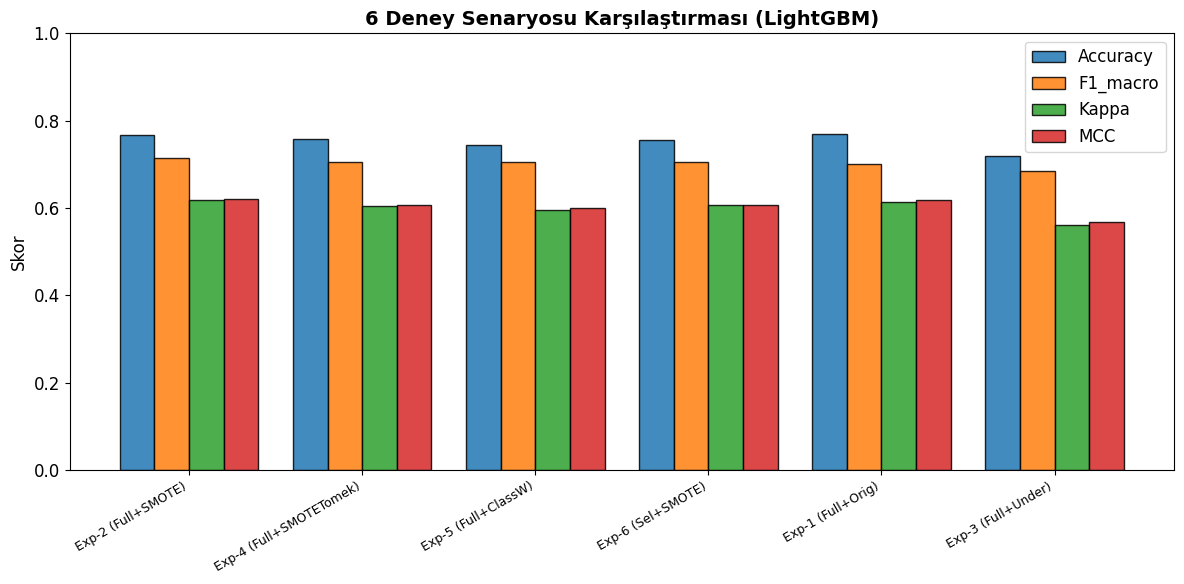


✅ Tamamlandı! Bu tabloyu makaledeki Tablo 6 ile değiştir.
Görsel: 17_scenario_comparison_lightgbm.png


In [ ]:
# =============================================================================
# TABLO 6 DÜZELTMESİ: 6 Senaryo Karşılaştırması (LightGBM ile)
# =============================================================================
# Bu kodu Colab'da SON hücreden sonra yeni bir hücreye yapıştır ve çalıştır.
# Süre: ~5 dakika
# =============================================================================

print("=" * 70)
print("6 DENEY SENARYOSU - LightGBM İLE KARŞILAŞTIRMA")
print("=" * 70)

# LightGBM'in tuned parametrelerini al
if 'LightGBM' in best_estimators:
    lgb_params = best_estimators['LightGBM'].named_steps['clf'].get_params()
else:
    lgb_params = {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.01,
                  'subsample': 0.8, 'num_leaves': 31, 'random_state': RANDOM_STATE,
                  'verbose': -1, 'n_jobs': -1}

scenario_configs_lgb = {
    'Exp-1 (Full+Orig)':       (X_train_full, y_train, X_test_full, False),
    'Exp-2 (Full+SMOTE)':      (X_train_smote_full, y_train_smote, X_test_full, False),
    'Exp-3 (Full+Under)':      (X_train_under_full, y_train_under, X_test_full, False),
    'Exp-4 (Full+SMOTETomek)': (X_train_st_full, y_train_st, X_test_full, False),
    'Exp-5 (Full+ClassW)':     (X_train_full, y_train, X_test_full, True),
    'Exp-6 (Sel+SMOTE)':       (X_train_smote_sel, y_train_smote_sel, X_test_selected, False),
}

scenario_results_lgb = {}
for exp_name, (X_tr, y_tr, X_te, use_cw) in scenario_configs_lgb.items():
    params = {k: v for k, v in lgb_params.items() if k not in ['class_weight']}
    if use_cw:
        params['class_weight'] = 'balanced'

    lgb_exp = lgb.LGBMClassifier(**params)
    lgb_exp.fit(X_tr, y_tr)
    yp = lgb_exp.predict(X_te)

    scenario_results_lgb[exp_name] = {
        'Accuracy': accuracy_score(y_test, yp),
        'F1_macro': f1_score(y_test, yp, average='macro', zero_division=0),
        'Kappa': cohen_kappa_score(y_test, yp),
        'MCC': matthews_corrcoef(y_test, yp)
    }
    print(f"  ✓ {exp_name}")

# Sonuç tablosu
scenario_df_lgb = pd.DataFrame(scenario_results_lgb).T
scenario_df_lgb = scenario_df_lgb.sort_values('F1_macro', ascending=False)

print("\n" + "=" * 70)
print("TABLO 6 (MAKALE İÇİN) - LightGBM ile 6 Senaryo")
print("=" * 70)
print(scenario_df_lgb.to_string(float_format='%.4f'))

# Kaydet
scenario_df_lgb.to_csv(os.path.join(DATA_DIR, 'scenario_comparison_lightgbm.csv'))

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(scenario_df_lgb))
w = 0.2
for i, col in enumerate(['Accuracy', 'F1_macro', 'Kappa', 'MCC']):
    ax.bar(x + i*w, scenario_df_lgb[col], w, label=col, alpha=0.85, edgecolor='black')
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(scenario_df_lgb.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Skor')
ax.set_title('6 Deney Senaryosu Karşılaştırması (LightGBM)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '17_scenario_comparison_lightgbm.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Tamamlandı! Bu tabloyu makaledeki Tablo 6 ile değiştir.")
print("Görsel: 17_scenario_comparison_lightgbm.png")